# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *64*  
**Kaggle challenge:** *Classic*   
**Kaggle team name (exact):** "*Team Nah!*"  

**Author 1 (sciper):** Andrew Brown (370751)  
**Author 2 (sciper):** Nour Lachat (302397)   
**Author 3 (sciper):** Henry Farrell (402247) 

**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

> Your comments  
> ...

In [5]:
import src.lab1 as lab1 
import src.lab_01_utils as lab1utils
import src.lab2 as lab2
import src.lab_02_utils as lab2utils
import src.lab3 as lab3
import src.lab_03_utils as lab3utils
import src.preprocessing as pre
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from skimage.morphology import remove_small_objects, remove_small_holes, closing, disk, opening
from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import cv2
from typing import Literal, Callable
import math


In [6]:
# Load the Datasets
references_path = "../data/dataset_project_iapr2025/references"
reference_images_raw, reference_labels, reference_dict = pre.load_reference_images(references_path)


train_path = "../data/dataset_project_iapr2025/train"
train_images_raw, train_labels, train_dict = pre.load_train_images(train_path)

In [7]:
# Print Shape of Images
print(f"Reference images shape: {reference_images_raw[0].shape}")
print(f"Train images shape: {train_images_raw[0].shape}")

Reference images shape: (4000, 6000, 3)
Train images shape: (4000, 6000, 3)


In [8]:
reference_images = reference_images_raw.copy()
train_images = train_images_raw.copy()

# Downsample the images and update the reference_images list and dictionary
for i, imgs in enumerate(reference_images):
    # Downsample the image using grid method
    downsampled_grid = pre.downsample_image(
        imgs,
        method="grid",
        target_height=400,
        target_width=600  # Only one dimension needs specification
    )

    # Update the reference_images list with the downsampled images
    reference_images[i] = downsampled_grid
    reference_dict[reference_labels[i]] = downsampled_grid


# Do the same with the train images
for i, imgs in enumerate(train_images):
    # Downsample the image using grid method
    downsampled_grid = pre.downsample_image(
        imgs,
        method="grid",
        target_height=400,
        target_width=600  # Only one dimension needs specification
    )

    # Update the reference_images list with the downsampled images
    train_images[i] = downsampled_grid
    train_dict[train_labels[i]] = downsampled_grid



In [9]:
# Print New Image Shape vs Old Image Shape
print(f"Old Image Shape: {train_images_raw[0].shape}")
print(f"New Image Shape: {train_images[0].shape}")


Old Image Shape: (4000, 6000, 3)
New Image Shape: (400, 600, 3)


In [10]:

# def joint_kmeans_downsample(
#     images: list[np.ndarray],
#     n_colors: int = 256
# ) -> tuple[list[np.ndarray], np.ndarray]:
#     """
#     Applies k-means color quantization jointly across all images and returns both the quantized images
#     and the learned color profile (cluster centers).
    
#     Args:
#         images: List of RGB images (H, W, 3)
#         n_colors: Number of color clusters to learn
    
#     Returns:
#         quantized_images: List of images with reduced color palette
#         color_profile: Array of shape (n_colors, 3), the shared color centers
#     """
#     # Flatten and concatenate all pixels from all images
#     pixel_arrays = [img.reshape(-1, 3) for img in images]
#     all_pixels = np.concatenate(pixel_arrays, axis=0)

#     # Fit KMeans to all image pixels
#     kmeans = MiniBatchKMeans(n_clusters=n_colors, random_state=0, batch_size=1024)
#     kmeans.fit(all_pixels)

#     # Quantize each image using the learned centers
#     quantized_images = []
#     for img in images:
#         flat_img = img.reshape(-1, 3)
#         labels = kmeans.predict(flat_img)
#         quantized = kmeans.cluster_centers_[labels].reshape(img.shape).astype(np.uint8)
#         quantized_images.append(quantized)

#     return quantized_images, kmeans.cluster_centers_.astype(np.uint8)

# def plot_color_profile(color_profile: np.ndarray, swatch_size: int = 2, cols: int = 32):
#     """
#     Plots a grid of color swatches from the color profile.

#     Args:
#         color_profile (np.ndarray): Array of shape (n_colors, 3)
#         swatch_size (int): Size of each square swatch in pixels
#         cols (int): Number of columns in the grid
#     """
#     n_colors = color_profile.shape[0]
#     rows = (n_colors + cols - 1) // cols

#     # Create a blank image to hold swatches
#     grid = np.zeros((rows * swatch_size, cols * swatch_size, 3), dtype=np.uint8)

#     for idx, color in enumerate(color_profile):
#         row = idx // cols
#         col = idx % cols
#         grid[
#             row * swatch_size : (row + 1) * swatch_size,
#             col * swatch_size : (col + 1) * swatch_size
#         ] = color.astype(np.uint8)

#     plt.figure(figsize=(cols / 2, rows / 2))
#     plt.imshow(grid)
#     plt.axis("off")
#     plt.title(f"{n_colors} Color Profile")
#     plt.show()

In [11]:
# reference_images_downsampled, reference_color_profile = joint_kmeans_downsample(reference_images, n_colors=256)
# print(f"Reference color profile shape: {reference_color_profile.shape}")
# plot_color_profile(reference_color_profile)

In [12]:
# # Downsample the images and update the reference_images list and dictionary
# for i, imgs in enumerate(reference_images):
#     # Downsample the image using grid method
#     downsampled_reference = pre.downsample_image(
#         imgs,
#         method="kmeans",
#         n_colors= 256
#     )

#     # Update the reference_images list with the downsampled images
#     reference_images[i] = downsampled_reference
#     reference_dict[reference_labels[i]] = downsampled_reference


# # Do the same with the train images
# for i, imgs in enumerate(train_images):
#     # Downsample the image using grid method
#     downsampled_train = pre.downsample_image(
#         imgs,
#         method="kmeans",
#         n_colors= 256
#     )

#     # Update the reference_images list with the downsampled images
#     train_images[i] = downsampled_train
#     train_dict[train_labels[i]] = downsampled_train

In [13]:
def extract_from_dictionary(dictionary, labels, keys: list) -> list:
    """
    Extracts values from a dictionary based on a list of keys.
    
    Args:
        dictionary: The input dictionary
        labels: List of labels to extract values from
        keys: List of keys to extract values for
    
    Returns:
        List of extracted values
    """
    extracted_values = []  # Initialize an empty list to store results
    for label in labels:
        if label in dictionary:
            dict_entry = dictionary[label]
            for key in keys:
                if key in dict_entry:
                    extracted_values.append(dict_entry[key])
                else:
                    extracted_values.append(None)
        else:
            extracted_values.append(None)
    return list(np.squeeze(np.array(extracted_values)))

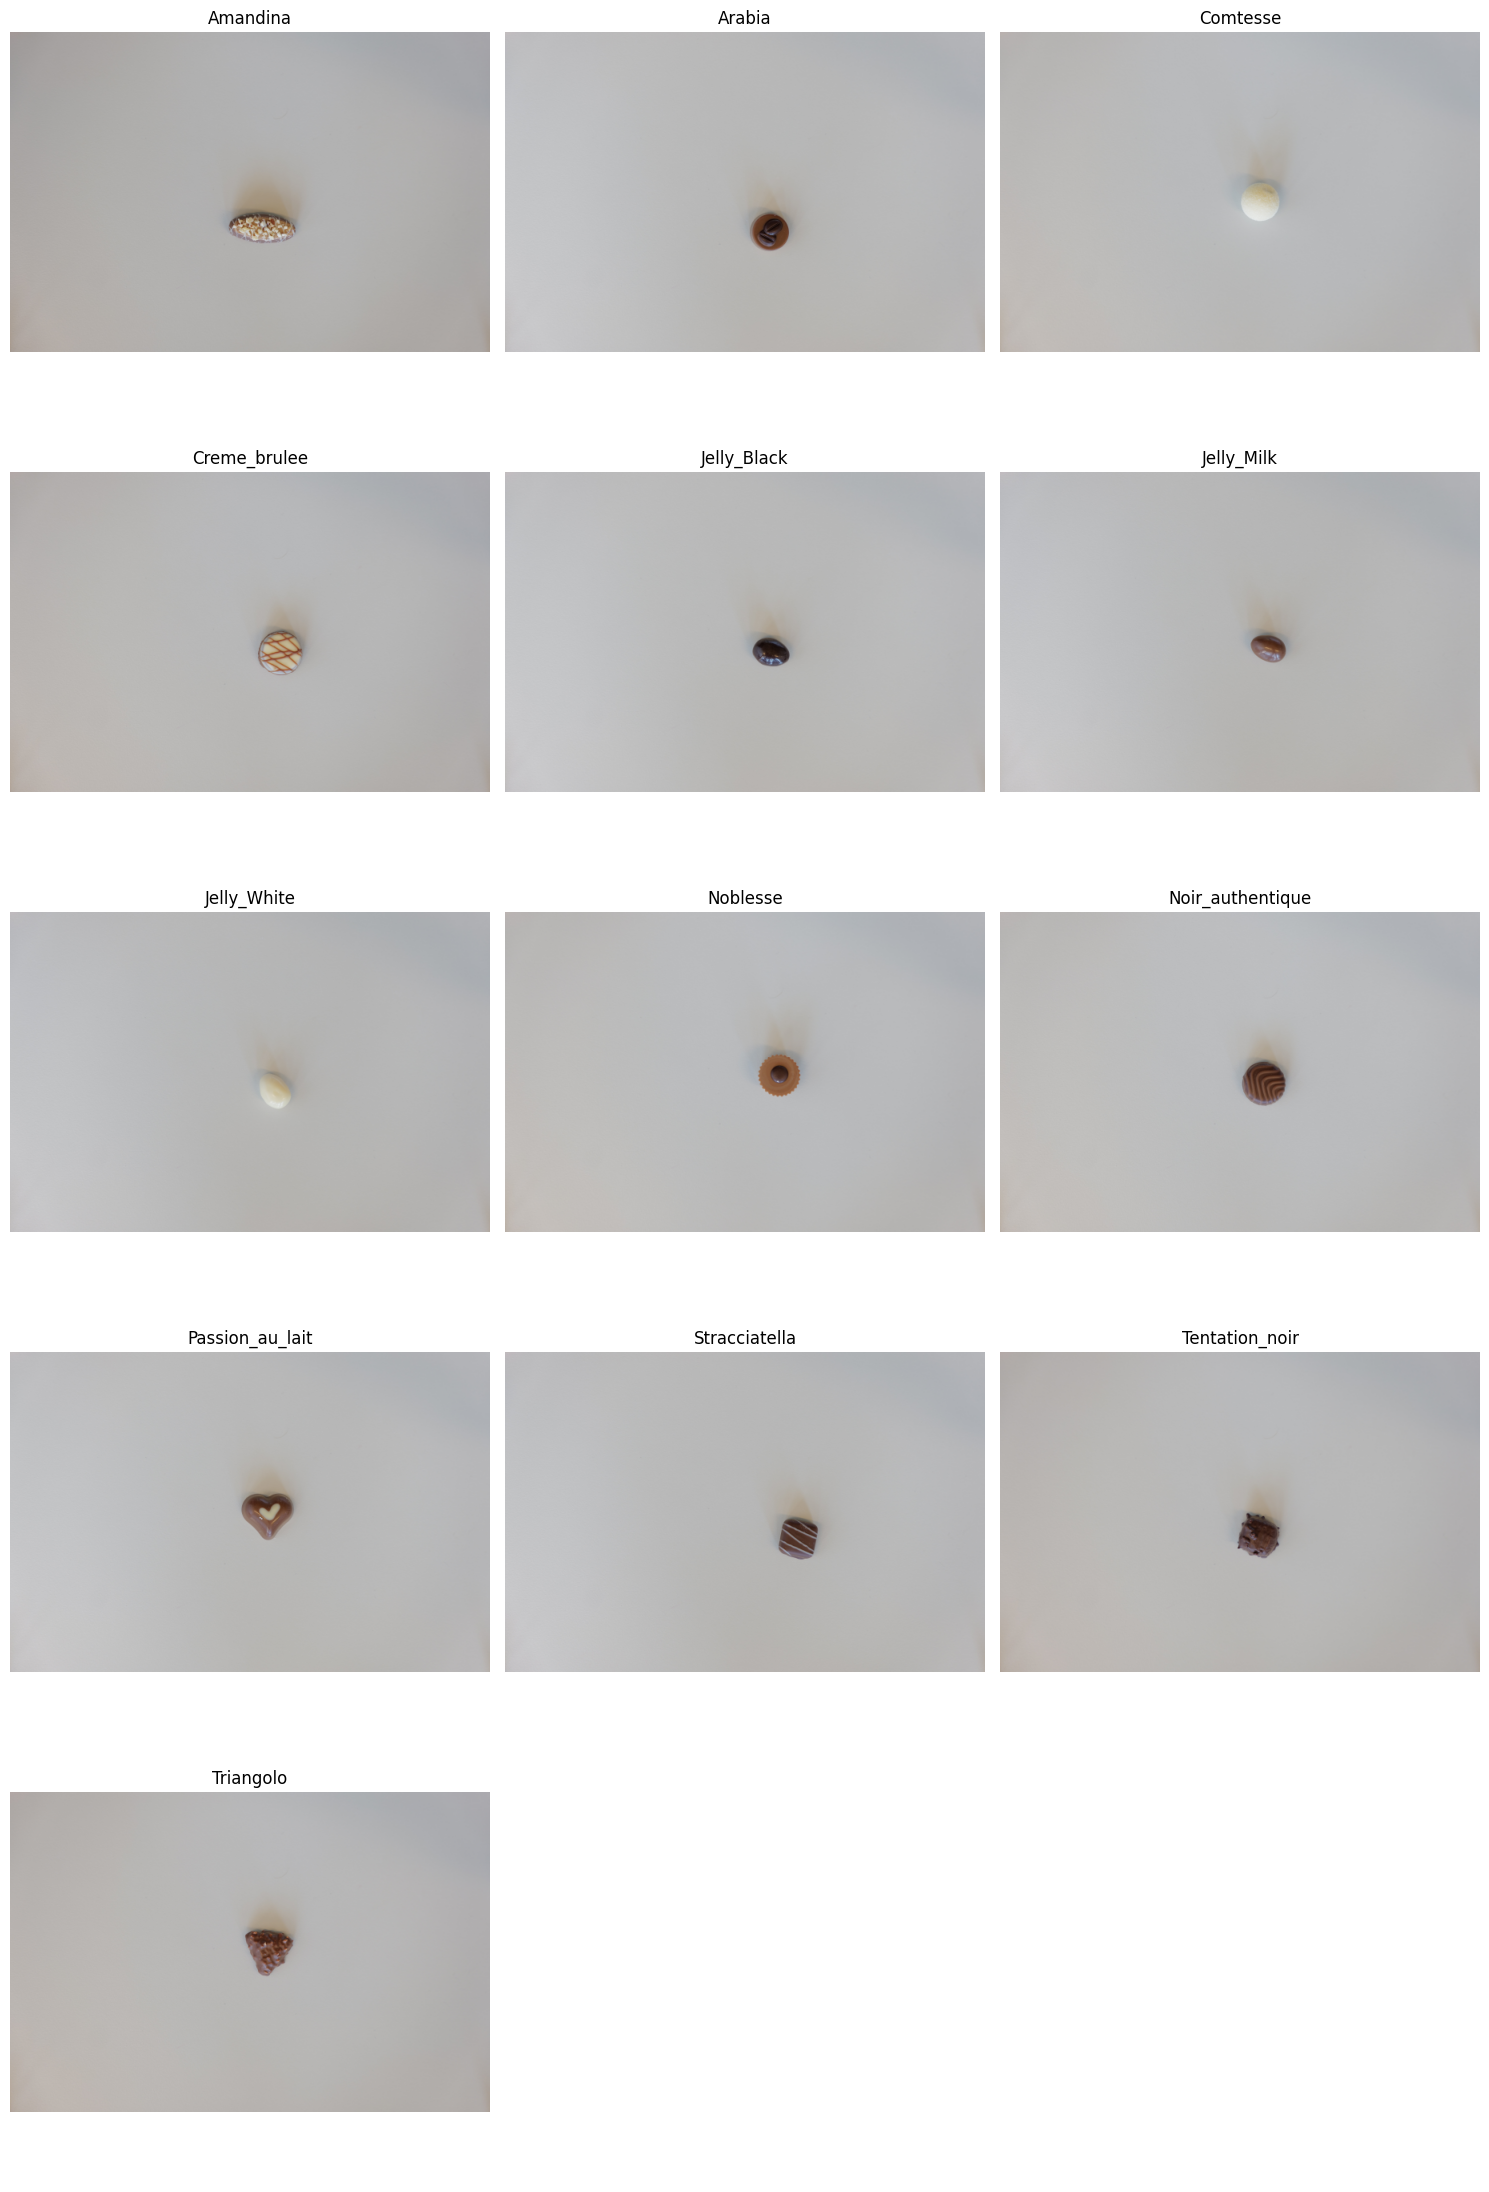

In [14]:
pre.plot_reference_images(reference_images, reference_labels)

## Section 1: Pre-Processing and Background Removal For Reference Images
The goal here is to take every image and separate the background from the foreground. This will make future isoltion, cropping, and classification much easier.

In [15]:
# ### Remove the background of all the reference images ###

# def bgremove2(myimage):
#     # First Convert to Grayscale
#     myimage_grey = cv2.cvtColor(myimage, cv2.COLOR_BGR2GRAY)
 
#     ret,baseline = cv2.threshold(myimage_grey,127,255,cv2.THRESH_TRUNC)
 
#     ret,background = cv2.threshold(baseline,126,255,cv2.THRESH_BINARY)
 
#     ret,foreground = cv2.threshold(baseline,126,255,cv2.THRESH_BINARY_INV)
 
#     foreground = cv2.bitwise_and(myimage,myimage, mask=foreground)  # Update foreground with bitwise_and to extract real foreground
 
#     # Convert black and white back into 3 channel greyscale
#     background = cv2.cvtColor(background, cv2.COLOR_GRAY2BGR)
 
#     # Combine the background and foreground to obtain our final image
#     finalimage = background+foreground
#     return finalimage

# # Apply the background removal to the reference images
# reference_images_nobg = reference_images_raw.copy()
# for i, imgs in enumerate(reference_images_raw):
#     # Apply the background removal
#     img_bgremoved = bgremove2(imgs)
    
#     # Update the reference_images list with the background removed images
#     reference_images_nobg[i] = img_bgremoved


In [16]:
# # Plot the original image and the background removed image
# k = 3
# # Compare the original image and the background removed image
# pre.compare_2_images(
#     image1=reference_images_raw[k],
#     image2=reference_images_nobg[k],
#     title="Original vs Background Removed Image")
# print(f"Original image shape: {reference_images_raw[k].shape}")
# print(f"Background removed image shape: {reference_images_nobg[k].shape}")

#### PREPROCESS THE REFERENCE IMAGES ####

In [17]:
### PREPROCESS REFERENCE IMAGES ###
# Canny Edge Detection Params
t_lower = 40
t_upper = 85 
aperture_size = 3 
L2Gradient = False

#Morphology Params
kernel_size=12
min_area_th=1
min_obj_size=100
connect=1

# Start by extracting the RGB data from all the images
N = len(reference_labels)

for i in range(N):
    label = reference_labels[i]
    img = reference_images[i]
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(img)
    H, S, V = lab1.extract_hsv_channels(img)
    
    # Update the dictionary to include the RGB channels
    reference_dict[label] = {
        "image": img,  # Original image
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,  # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    }

# # Add all of the raw images to the dictionary
# for i, dict in enumerate(reference_dict.values()):
#     # Extrat Raw Image
#     img = reference_images_raw[i]

#     # Add the new key-value pair to the dictionary
#     dict["raw_image"] = img

# Convert the images to grayscale and add the grayscale images to the dictionary
for dict in reference_dict.values():
    # Extract the image from the dictionary
    img = dict["image"]
    # raw_img = dict["raw_image"]
    
    # Apply the HSV thresholding
    img_grey = pre.RGB2greyscale(img)
    # img_grey_raw = pre.RGB2greyscale(raw_img)
    
    # Add the new key-value pair to the dictionary
    dict["grey"] = img_grey
    # dict["grey_raw"] = img_grey_raw


# Apply Canny edge detection to the images and add the Canny images to the dictionary
for dict in reference_dict.values():
    # Extract the image from the dictionary
    img = np.uint8(dict["grey"])
    
    # Apply the Canny edge detection
    img_canny = cv2.Canny(img, t_lower, t_upper, apertureSize=aperture_size, L2gradient=L2Gradient)
    
    # Add the new key-value pair to the dictionary
    dict["canny"] = img_canny

# Apply morphology to the Canny edge-detected image
for dict in reference_dict.values():
    # Extract the image from the dictionary
    img = dict["canny"]
    
    # Apply the morphology
    img_morph = lab1.apply_morphology(img, kernel_size=kernel_size, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    
    # Add the new key-value pair to the dictionary
    dict["canny_morph"] = img_morph

c:\Users\sunde\Desktop\Local_Repos\ImageAnalysisAndPatternRecognitionGroupWork\project\src\lab1.py:275: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  img_morph = remove_small_holes(img_morph, area_threshold=min_area_th, connectivity=connect, out=None)


In [18]:
### Find a single bounding box surrouning all contours in each reference image with the contours aroud the canny ###

def find_bounding_box(image: np.ndarray, contours: list) -> tuple[int, int, int, int]:
    """
    Find a single bounding box surrounding all contours in the image.

    
    Args:
        image: Input image (H, W, 3)
        contours: List of contours found in the image

    Returns:
        x_min, y_min, x_max, y_max: Coordinates of the bounding box
    """
    # Initialize min and max coordinates
    x_min = image.shape[1]
    y_min = image.shape[0]
    x_max = 0
    y_max = 0

    for contour in contours:
        # Get the bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)
        
        # Update min and max coordinates
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)
    
    return x_min, y_min, x_max, y_max

# First pass: Find individual bounding boxes and determine max dimensions
bounding_boxes = []
max_width = 0
max_height = 0

for k in range(13):
    dict_entry = reference_dict[reference_labels[k]]
    img = dict_entry["canny"]

    # Find contours
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find bounding box around all contours
    x_min, y_min, x_max, y_max = find_bounding_box(img, contours)

    # Store bounding box
    bounding_boxes.append((x_min, y_min, x_max, y_max))

    # Update max width and height
    padding = 3
    width = x_max - x_min
    height = y_max - y_min
    max_width = max(max_width, width) + padding
    max_height = max(max_height, height) + padding

cropped_refrence_images = []
# Second pass: Re-extract bounding boxes using uniform size
for k in range(13):
    dict_entry = reference_dict[reference_labels[k]]
    og_img = reference_images[k]
    img = dict_entry["canny"]
    x_min, y_min, x_max, y_max = bounding_boxes[k]

    # Centered bounding box with uniform size
    center_x = (x_min + x_max) // 2
    center_y = (y_min + y_max) // 2

    new_x_min = max(center_x - max_width // 2, 0)
    new_y_min = max(center_y - max_height // 2, 0)
    new_x_max = min(new_x_min + max_width, og_img.shape[1])
    new_y_max = min(new_y_min + max_height, og_img.shape[0])

    # Save bounding box info
    dict_entry["contour_bounding_box"] = (new_x_min, new_y_min, new_x_max, new_y_max)

    # Extract and save cropped image
    bbox_image = og_img[new_y_min:new_y_max, new_x_min:new_x_max]
    dict_entry["bbox_image"] = bbox_image

    # Optional: draw rectangle on image
    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (new_x_min, new_y_min), (new_x_max, new_y_max), (255, 0, 0), 2)
    dict_entry["image_with_box"] = img_with_box
    cropped_refrence_images.append(bbox_image)

    # print(f"Uniform Bounding Box Shape: {bbox_image.shape}")
    # Plot the bbox image
    # plt.imshow(bbox_image)
    # plt.axis("off")
    # plt.title("Bounding Box Image")
    # plt.show()



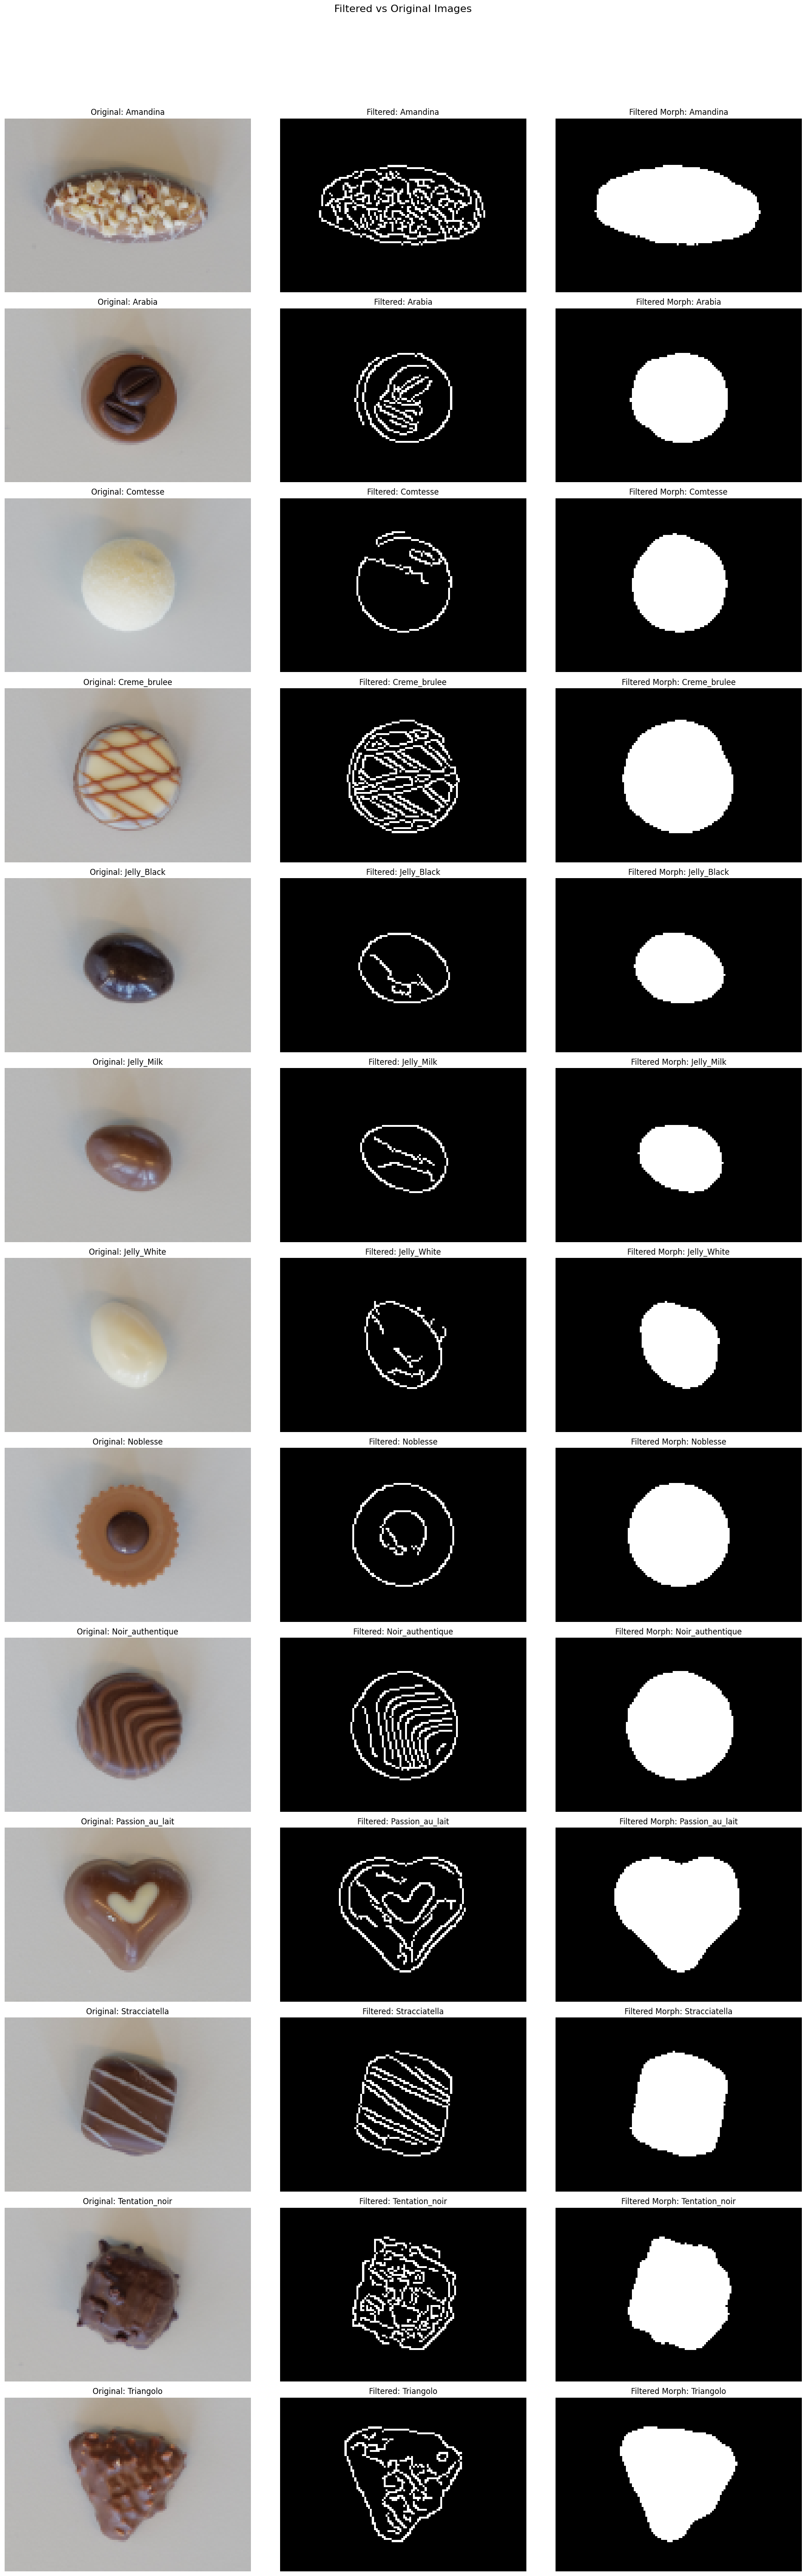

In [19]:
### Make New Dictonary with the cropped images and Apply Preprocessing ###

# Create a new dictionary for cropped images
cropped_reference_dict = {}
for i, label in enumerate(reference_labels):
    cropped_reference_dict[label] = {
        "image": cropped_refrence_images[i],
    }

# Define Parameters
t_lower = [30, 30, 15, 30, 30, 30, 10, 30, 30, 30, 30, 10, 30]
t_upper = [115, 115, 115, 115, 115, 115, 80, 115, 115, 115, 115, 90, 115]
aperture_size = 3
L2Gradient = False

# Make the parameters dynamic to tailor the shapes
kernel_size = [6, 10, 16, 10, 12, 14, 12, 16, 4, 8, 6, 5, 8]
min_area_th = 10
min_obj_size = 20
connect = 2

# Dynamic Gaussian Blur 
blur = [5, 3, 3, 3, 9, 7, 1, 7, 5, 3, 5, 1, 5]


# Apply the same preprocessing steps to the cropped images
for i, imgs in enumerate(cropped_refrence_images):
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(imgs)
    H, S, V = lab1.extract_hsv_channels(imgs)
    
    # Update the dictionary to include the RGB channels
    cropped_reference_dict[reference_labels[i]].update({
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,  # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    })

    # Convert to grayscale
    img_grey = np.uint8(pre.RGB2greyscale(imgs))
    cropped_reference_dict[reference_labels[i]]["grey"] = img_grey

    # Add a bit of gaussian blur to the images
    img_blury = cv2.GaussianBlur(img_grey, (blur[i], blur[i]), 0)
    cropped_reference_dict[reference_labels[i]]["grey_blur"] = img_blury

    # Apply Canny edge detection
    img_canny = cv2.Canny(img_blury, t_lower[i], t_upper[i], apertureSize=aperture_size, L2gradient=L2Gradient)
    cropped_reference_dict[reference_labels[i]]["canny"] = img_canny

    # Apply morphology
    img_morph = lab1.apply_morphology(img_canny, kernel_size=kernel_size[i], min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    cropped_reference_dict[reference_labels[i]]["canny_morph"] = img_morph

pre.plot_ref_images_vs_filtered(cropped_reference_dict, reference_labels)




In [20]:
# Find contours of reference images and Add to Dictionary #

for i, dict in enumerate(cropped_reference_dict.values()):
    # Extract the image from the dictionary
    img = dict["canny_morph"]
    
    # Add an extra dimension to img
    img = np.expand_dims(img, axis=0)  # Shape becomes (1, H, W)
    
    # Find contours
    contours = lab2.find_contour(img)
    
    # Add the new key-value pair to the dictionary
    dict["contours"] = contours

In [21]:
def compute_shape_features(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    rect = cv2.boundingRect(contour)
    bounding_area = rect[2] * rect[3]
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)
    rectangularity = area / (bounding_area + 1e-6)
    extent = area / (hull_area + 1e-6)
    
    return [area, perimeter, compactness, rectangularity, extent]

In [22]:
# Compute shape features for each contour and add to the dictionary #
for dict in cropped_reference_dict.values():
    # Shape features
    features = ["area", "perimeter", "compactness", "rectangularity", "extent"]

    # Extract the image from the dictionary
    img = dict["contours"]
    
    # Compute shape features for each contour
    shape_features = [compute_shape_features(c) for c in img]
    
    # Add the new key-value pair to the dictionary
    for i, feature in enumerate(features):
        dict[feature] = [f[i] for f in shape_features]

    # Add the shape features to the dictionary
    dict["shape_features"] = shape_features

In [23]:
# from sklearn.neighbors import KNeighborsClassifier

# # Build feature matrix for reference images
# reference_features = []
# for contour in contours_list:
#     # If multiple contours, you may want to select the largest one
#     if contour is not None and contour.size > 0:
#         if contour.ndim == 3:
#             contour = contour.reshape(-1, 2)
#         features = compute_shape_features(contour)
#     else:
#         features = [0, 0, 0, 0, 0]  # Or np.nan, depending on your needs
#     reference_features.append(features)

# reference_features = np.array(reference_features)
# reference_labels_array = np.array(reference_labels)

# knn = KNeighborsClassifier(n_neighbors=3)
# knn.fit(reference_features, reference_labels_array)

# # Suppose you have a new contour from a test image
# test_contour = contours_list[0]  # Replace with your test contour
# if test_contour is not None and test_contour.size > 0:
#     if test_contour.ndim == 3:
#         test_contour = test_contour.reshape(-1, 2)
#     test_features = np.array(compute_shape_features(test_contour)).reshape(1, -1)
#     predicted_label = knn.predict(test_features)
#     print("Predicted chocolate:", predicted_label[0])
# else:
#     print("No contour found in test image.")

In [24]:
import seaborn as sns
import pandas as pd

# Extract Reference Features
reference_features = extract_from_dictionary(cropped_reference_dict, reference_labels, ["shape_features"])

feature_names = ["Area", "Perimeter", "Compactness", "Rectangularity", "Extent"]
df = pd.DataFrame(reference_features, columns=feature_names)
df['Label'] = reference_labels

# Create a unique color palette based on number of unique labels
unique_labels = df['Label'].unique()
palette = sns.color_palette("hls", len(unique_labels))  # or try "husl", "Set3", etc.

# 2D scatter plot: Area vs Compactness
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Area", y="Compactness", hue="Label", palette=palette, s=80)
plt.title("Chocolate Shape Features: Area vs Compactness")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Pairplot for all features (optional)
sns.pairplot(df, hue="Label", corner=True, diag_kind="kde", palette=palette)
plt.suptitle("Pairplot of Shape Features", y=1.02)
plt.show()

ModuleNotFoundError: No module named 'seaborn'

Amandina avg color: 160 139 117
Amandina primary color fraction: 0.6613333333333333 Amandina secondary color fraction: 0.33866666666666667
Amandina primary color: 177 162 142 Amandina secondary color: 127 94 66
Arabia avg color: 73 48 39
Arabia primary color fraction: 0.5701320132013201 Arabia secondary color fraction: 0.4298679867986799
Arabia primary color: 91 57 40 Arabia secondary color: 46 28 24
Comtesse avg color: 203 198 179
Comtesse primary color fraction: 0.5222135619641466 Comtesse secondary color fraction: 0.47778643803585347
Comtesse primary color: 217 217 207 Comtesse secondary color: 188 178 148
Creme_brulee avg color: 173 143 115
Creme_brulee primary color fraction: 0.5207547169811321 Creme_brulee secondary color fraction: 0.47924528301886793
Creme_brulee primary color: 163 121 89 Creme_brulee secondary color: 186 173 148
Jelly_Black avg color: 56 48 53
Jelly_Black primary color fraction: 0.5942782834850455 Jelly_Black secondary color fraction: 0.4057217165149545
Jelly_B

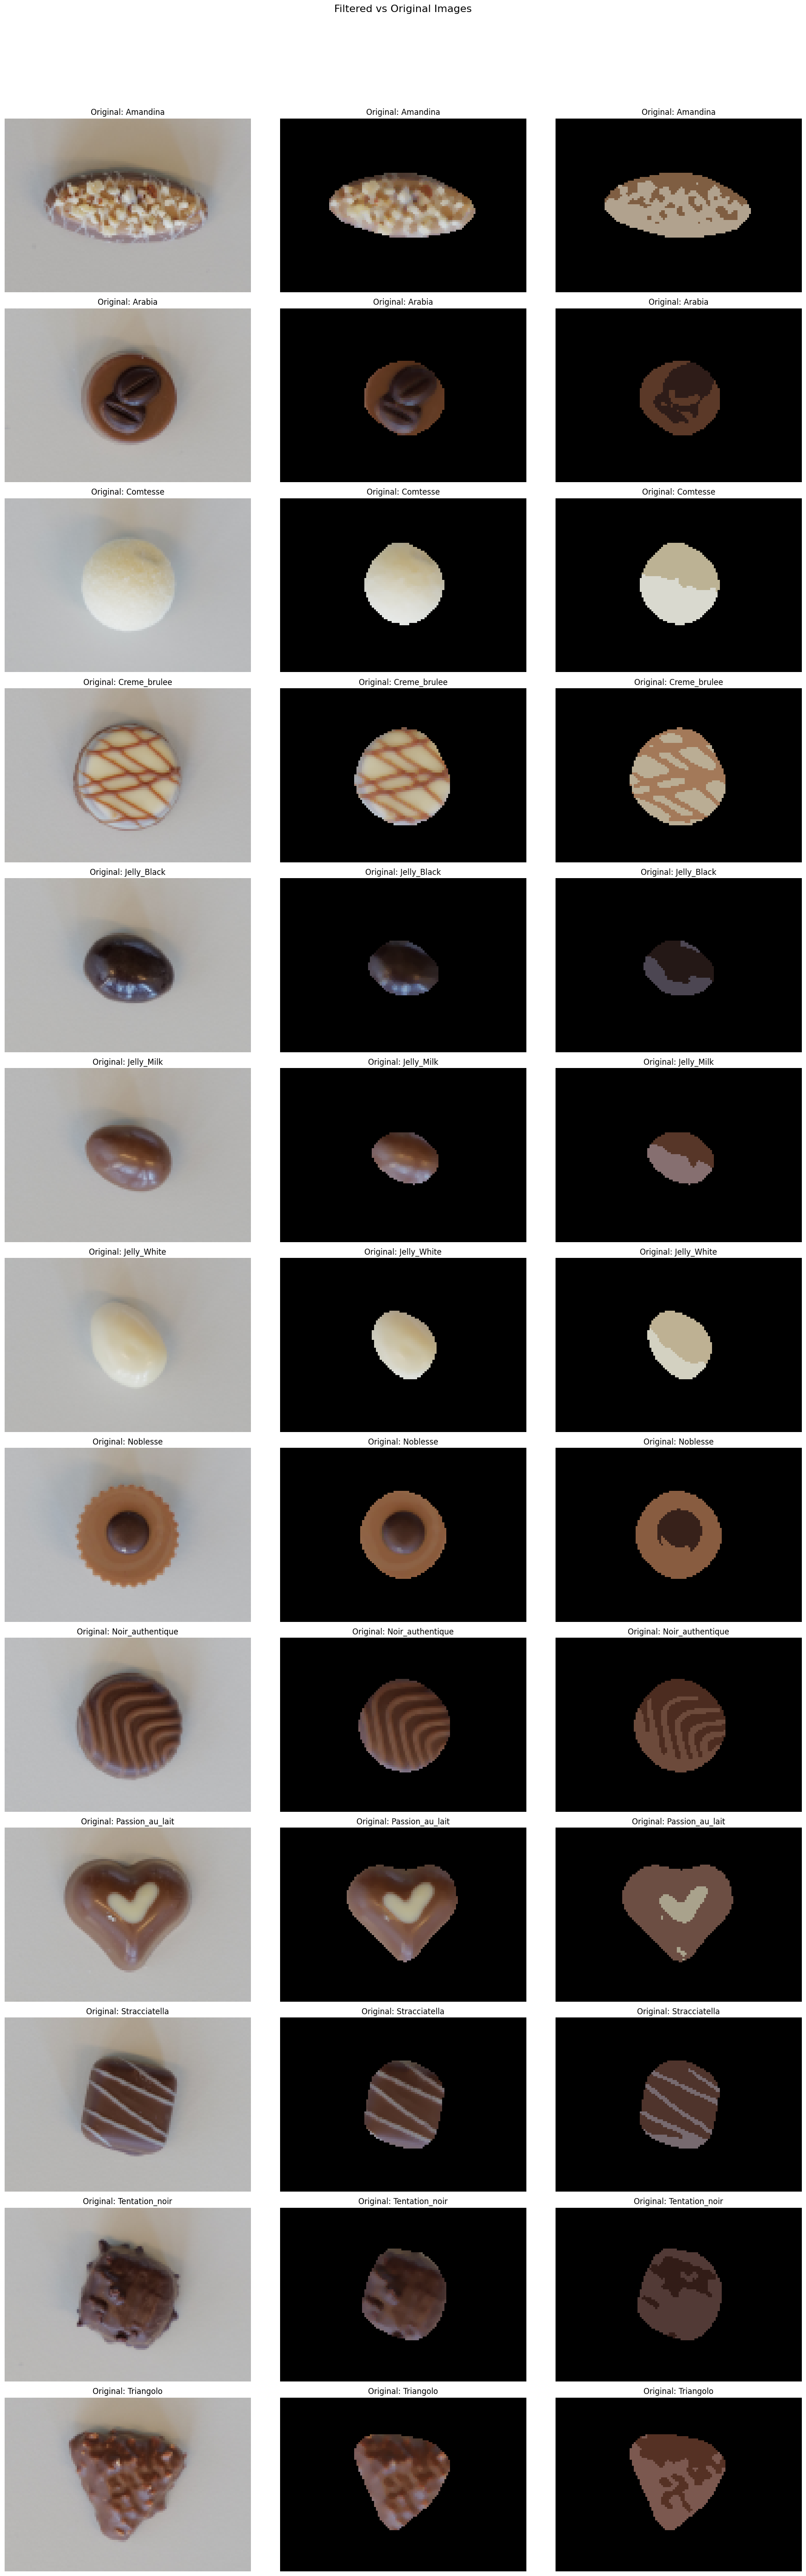

In [66]:

def plot_color_list_histo(
    colors: np.ndarray,
    func: Callable,
    labels: list[str],
):
    """
    Plot scatterplots showing the distribution of color channels for a list of RGB colors.

    Args
    ----
    colors: np.ndarray (N, 3)
        Array of RGB colors, shape N x 3, values expected in 0–255 range.
    func: Callable
        Function that transforms the color list into D channels (e.g., RGB, LAB, HSV).
    labels: list of str
        Names of the channels extracted by func, e.g., ["R", "G", "B"].
    """
    if colors.ndim != 2 or colors.shape[1] != 3:
        raise ValueError("Input 'colors' must be of shape (N, 3)")

    colors = colors.astype(np.uint8)
    transformed = func(img=colors)
    C = len(transformed)

    if C != len(labels):
        raise ValueError("Number of channels returned by func must match number of labels.")

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].scatter(transformed[0], transformed[1], c=colors / 255.0, s=10, alpha=0.5)
    axs[0].set_xlabel(labels[0])
    axs[0].set_ylabel(labels[1])
    axs[0].set_title(f"{labels[0]} vs {labels[1]}")

    axs[1].scatter(transformed[0], transformed[2], c=colors / 255.0, s=10, alpha=0.5)
    axs[1].set_xlabel(labels[0])
    axs[1].set_ylabel(labels[2])
    axs[1].set_title(f"{labels[0]} vs {labels[2]}")

    axs[2].scatter(transformed[1], transformed[2], c=colors / 255.0, s=10, alpha=0.5)
    axs[2].set_xlabel(labels[1])
    axs[2].set_ylabel(labels[2])
    axs[2].set_title(f"{labels[1]} vs {labels[2]}")

    plt.tight_layout()
    plt.show()

def extract_rgb(img):
    return [img[:, 0], img[:, 1], img[:, 2]]

def rgb_to_hsv_channels(img: np.ndarray) -> list[np.ndarray]:
    """
    Convert an array of RGB colors to HSV using OpenCV and return channels separately.

    Args
    ----
    img: np.ndarray (N, 3)
        Array of RGB values in 0–255 range.

    Returns
    -------
    List of np.ndarray: [H, S, V], each of shape (N,)
        H in [0, 360], S and V in [0, 1]
    """
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)

    img_bgr = img[:, ::-1]  # Convert RGB to BGR for OpenCV
    img_bgr = img_bgr[np.newaxis, :, :]  # Shape (1, N, 3) for cv2.cvtColor
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)[0]  # Shape (N, 3)

    h = hsv[:, 0].astype(np.float32) * 2        # OpenCV gives H in [0,179], convert to [0,360]
    s = hsv[:, 1].astype(np.float32) / 255.0    # Normalize to [0,1]
    v = hsv[:, 2].astype(np.float32) / 255.0    # Normalize to [0,1]
    
    return [h, s, v]

def plot_ref_images_vs_color_isolated(reference_dict, reference_labels):
    """
    Plot the original and filtered images for each reference image.
    Args:
        reference_dict (dict): Dictionary containing reference images and their properties.
        reference_labels (list): List of labels corresponding to the reference images.
    """

    # Calculate the number of rows needed for 3 columns
    num_rows = math.ceil(len(reference_labels))

    # Create a figure with subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 4.5 * num_rows))
    fig.suptitle("Filtered vs Original Images", fontsize=16)

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    for i, label in enumerate(reference_labels):
        # Original image (first column)
        original_image = reference_dict[label]['image']
        axes[i * 3].imshow(original_image)
        axes[i * 3].set_title(f"Original: {label}")
        axes[i * 3].axis('off')

        # Color Isolated (second column)
        original_image = reference_dict[label]['color_isolated_image']
        axes[i * 3 + 1].imshow(original_image)
        axes[i * 3 + 1].set_title(f"Original: {label}")
        axes[i * 3 + 1].axis('off')

        # Color Isolated (second column)
        original_image = reference_dict[label]['cluster_isolated_image']
        axes[i * 3 + 2].imshow(original_image)
        axes[i * 3 + 2].set_title(f"Original: {label}")
        axes[i * 3 + 2].axis('off')


        # Color Swatch (third column)
        # original_image = reference_dict[label]['color_swatch']
        # axes[i * 3 + 2].imshow(original_image)
        # axes[i * 3 + 2].set_title(f"Original: {label}")
        # axes[i * 3 + 2].axis('off')

    # Hide any unused subplots
    for j in range(len(reference_labels) * 3, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def kmeans_cv2(colors: np.ndarray, k: int = 2, attempts: int = 10):
    """
    Perform K-means clustering on RGB data using OpenCV.
    
    Args:
        colors (np.ndarray): Array of RGB values, shape (N, 3), dtype uint8 or float32.
        k (int): Number of clusters.
        attempts (int): Number of times the algorithm is executed using different initial labels.
    
    Returns:
        labels (np.ndarray): Cluster indices for each pixel.
        centers (np.ndarray): RGB values of cluster centers.
    """
    # Convert to float32 as required by OpenCV
    Z = colors.reshape((-1, 3)).astype(np.float32)

    # Define criteria: (type, max_iter, epsilon)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    # Apply KMeans
    ret, cluster_labels, cluster_centers = cv2.kmeans(
        Z, k, None, criteria, attempts, cv2.KMEANS_RANDOM_CENTERS
    )

    cluster_labels = cluster_labels.flatten()
    cluster_centers = cluster_centers.astype(np.uint8)

    return cluster_labels, cluster_centers

def kmeans_cv2_with_coordinates(img: np.ndarray, k: int = 3, attempts: int = 10):
    """
    Apply K-means clustering on the RGB values of non-black pixels in an image.
    Also preserves the (x, y) coordinates of the clustered pixels.

    Parameters
    ----------
    img : np.ndarray
        Input image (H, W, 3) in RGB or BGR format.
    k : int
        Number of clusters.
    attempts : int
        Number of times the algorithm is executed using different initial labellings.

    Returns
    -------
    cluster_labels : np.ndarray
        Cluster labels of shape (N,) for N non-black pixels.
    cluster_centers : np.ndarray
        Rounded RGB color centers of each cluster (k, 3), dtype uint8.
    coords : np.ndarray
        (y, x) coordinates of the non-black pixels, shape (N, 2).
    """
    # Ensure image is in uint8
    if img.dtype != np.uint8:
        raise ValueError("Image must be uint8")

    h, w, _ = img.shape
    pixels = img.reshape((-1, 3))
    indices = np.indices((h, w)).reshape(2, -1).T  # Shape (H*W, 2) → (y, x)

    # Filter out black pixels (0, 0, 0)
    mask = ~(np.all(pixels == [0, 0, 0], axis=1))
    pixels_nonblack = pixels[mask].astype(np.float32)
    coords_nonblack = indices[mask]

    if len(pixels_nonblack) == 0:
        raise ValueError("No non-black pixels found in the image.")

    # Run KMeans
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    compactness, cluster_labels, cluster_centers = cv2.kmeans(
        pixels_nonblack,
        k,
        None,
        criteria,
        attempts,
        flags=cv2.KMEANS_PP_CENTERS
    )

    cluster_labels = cluster_labels.flatten()  # Shape (N,)
    cluster_centers = np.round(cluster_centers).astype(np.uint8)  # Convert to nearest int

    return cluster_labels, cluster_centers, coords_nonblack

def merge_similar_clusters(cluster_centers, cluster_labels, threshold):
    """
    Merge clusters with similar colors based on a threshold distance between cluster centers.

    Args:
    -----
    cluster_centers: np.ndarray of shape (K, 3)
        The original RGB cluster centers (float or int).
    cluster_labels: np.ndarray of shape (N,)
        The label for each pixel in the image.
    threshold: float
        The distance threshold under which two clusters will be merged.

    Returns:
    --------
    new_cluster_centers: np.ndarray
        The updated cluster centers after merging.
    new_cluster_labels: np.ndarray
        The updated labels with merged cluster indices.
    """

    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    label_to_index = {label: i for i, label in enumerate(unique_labels)}

    # Create a working list of (center, count)
    clusters = [
        {"center": cluster_centers[label], "count": count, "original_labels": [label]}
        for label, count in zip(unique_labels, counts)
    ]

    merged = True
    while merged:
        merged = False
        # Nested loops replacing combinations()
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                c1, c2 = clusters[i], clusters[j]
                dist = np.linalg.norm(c1["center"] - c2["center"])
                if dist < threshold:
                    # Weighted average of centers
                    total = c1["count"] + c2["count"]
                    new_center = (c1["center"] * c1["count"] + c2["center"] * c2["count"]) / total
                    clusters[i] = {
                        "center": new_center,
                        "count": total,
                        "original_labels": c1["original_labels"] + c2["original_labels"],
                    }
                    clusters.pop(j)
                    merged = True
                    break  # Restart loop since clusters list changed
            if merged:
                break

    # Reassign pixels to merged clusters
    label_map = {}
    for new_idx, cluster in enumerate(clusters):
        for old_label in cluster["original_labels"]:
            label_map[old_label] = new_idx

    new_cluster_labels = np.array([label_map[label] for label in cluster_labels])
    new_cluster_centers = np.array([c["center"] for c in clusters]).astype(np.uint8)

    return new_cluster_centers, new_cluster_labels

def reduce_clusters(cluster_centers, cluster_labels, groups):
    """
    Iteratively merges the two closest clusters until only two remain.

    Args:
    -----
    cluster_centers: np.ndarray of shape (K, 3)
        The original RGB cluster centers (float or int).
    cluster_labels: np.ndarray of shape (N,)
        The label for each pixel in the image.

    Returns:
    --------
    new_cluster_centers: np.ndarray of shape (2, 3)
        The final two cluster centers after merging.
    new_cluster_labels: np.ndarray of shape (N,)
        The updated labels with only two unique values: 0 and 1.
    """
    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    
    # Create a working list of clusters with metadata
    clusters = [
        {"center": cluster_centers[label], "count": count, "original_labels": [label]}
        for label, count in zip(unique_labels, counts)
    ]

    while len(clusters) > groups:
        # Find the pair of clusters with the smallest distance
        min_dist = float('inf')
        pair_to_merge = (None, None)
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = np.linalg.norm(clusters[i]["center"] - clusters[j]["center"])
                if dist < min_dist:
                    min_dist = dist
                    pair_to_merge = (i, j)

        i, j = pair_to_merge
        c1, c2 = clusters[i], clusters[j]
        total = c1["count"] + c2["count"]
        new_center = (c1["center"] * c1["count"] + c2["center"] * c2["count"]) / total

        # Replace cluster i and remove cluster j
        clusters[i] = {
            "center": new_center,
            "count": total,
            "original_labels": c1["original_labels"] + c2["original_labels"]
        }
        clusters.pop(j)

    # Final centers
    new_cluster_centers = np.array([c["center"] for c in clusters], dtype=np.float32)

    # Map original labels to final cluster index (0 or 1)
    label_mapping = {}
    for new_label, cluster in enumerate(clusters):
        for orig_label in cluster["original_labels"]:
            label_mapping[orig_label] = new_label

    # Generate new cluster labels
    new_cluster_labels = np.array([label_mapping[label] for label in cluster_labels])

    return new_cluster_centers, new_cluster_labels

def merge_closest_by_hue(cluster_centers, cluster_labels):
    """
    Merge the two clusters with the most similar hue values, repeating until only two remain.

    Args:
    -----
    cluster_centers: np.ndarray of shape (K, 3)
        RGB cluster centers.
    cluster_labels: np.ndarray of shape (N,)
        Original cluster labels for each point.

    Returns:
    --------
    new_cluster_centers: np.ndarray of shape (2, 3)
        Final two RGB cluster centers.
    new_cluster_labels: np.ndarray of shape (N,)
        New labels (0 or 1) for each point.
    """
    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)

    # Convert RGB to HSV to extract hues
    def rgb_to_hue(rgb):
        rgb = np.array(rgb, dtype=np.uint8).reshape(-1, 1, 3)
        hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
        hue = hsv[:, 0, 0].astype(np.float32)  # in [0, 180]
        return hue

    clusters = [
        {
            "center": cluster_centers[label],
            "count": count,
            "original_labels": [label],
            "hue": rgb_to_hue(cluster_centers[label])[0],
        }
        for label, count in zip(unique_labels, counts)
    ]

    def hue_distance(h1, h2):
        # Circular hue distance: hue is in [0,180] for OpenCV HSV
        d = abs(h1 - h2)
        return min(d, 180 - d)

    while len(clusters) > 2:
        min_dist = float('inf')
        pair_to_merge = (None, None)

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                d = hue_distance(clusters[i]["hue"], clusters[j]["hue"])
                if d < min_dist:
                    min_dist = d
                    pair_to_merge = (i, j)

        i, j = pair_to_merge
        c1, c2 = clusters[i], clusters[j]
        total = c1["count"] + c2["count"]

        # Weighted RGB merge
        new_center = (c1["center"] * c1["count"] + c2["center"] * c2["count"]) / total
        new_hue = rgb_to_hue(new_center)[0]

        clusters[i] = {
            "center": new_center,
            "count": total,
            "original_labels": c1["original_labels"] + c2["original_labels"],
            "hue": new_hue,
        }
        clusters.pop(j)

    # Extract final RGB centers
    new_cluster_centers = np.array([c["center"] for c in clusters], dtype=np.float32)

    # Relabel based on merged groups
    label_mapping = {}
    for new_label, cluster in enumerate(clusters):
        for orig_label in cluster["original_labels"]:
            label_mapping[orig_label] = new_label

    new_cluster_labels = np.array([label_mapping[label] for label in cluster_labels])

    return new_cluster_centers, new_cluster_labels

def merge_smallest_with_closest_color(cluster_centers, cluster_labels, color_space='RGB'):
    """
    Iteratively merges the cluster with the fewest pixels into its closest neighbor in color space,
    keeping the color of the closest cluster. Stops when only two clusters remain.

    Args:
    -----
    cluster_centers : np.ndarray (K, 3)
        RGB cluster centers.
    cluster_labels : np.ndarray (N,)
        Cluster label for each pixel.
    color_space : str
        Either 'RGB' or 'HSV'. Determines the color space for distance calculation.

    Returns:
    --------
    new_cluster_centers : np.ndarray (2, 3)
        Final two cluster centers in RGB.
    new_cluster_labels : np.ndarray (N,)
        Updated cluster labels (0 or 1).
    """
    cluster_centers = np.array(cluster_centers, dtype=np.float32)
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)

    def rgb_to_hsv(rgb):
        rgb = np.array(rgb, dtype=np.uint8).reshape(1, 1, 3)
        hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        return hsv[0, 0]

    def color_distance(c1, c2):
        if color_space == 'HSV':
            c1 = rgb_to_hsv(c1)
            c2 = rgb_to_hsv(c2)
        return np.linalg.norm(c1 - c2)

    # Initialize cluster list
    clusters = [
        {
            "center": cluster_centers[label],
            "count": count,
            "original_labels": [label],
        }
        for label, count in zip(unique_labels, counts)
    ]

    while len(clusters) > 2:
        # Find cluster with fewest pixels
        smallest_idx = np.argmin([c["count"] for c in clusters])
        smallest = clusters[smallest_idx]

        # Find its closest neighbor
        min_dist = float('inf')
        closest_idx = None
        for i, cluster in enumerate(clusters):
            if i == smallest_idx:
                continue
            dist = color_distance(smallest["center"], cluster["center"])
            if dist < min_dist:
                min_dist = dist
                closest_idx = i

        # Merge smallest into closest (keep closest cluster's color)
        c1, c2 = smallest, clusters[closest_idx]
        total = c1["count"] + c2["count"]
        new_center = c2["center"]

        new_cluster = {
            "center": new_center,
            "count": total,
            "original_labels": c1["original_labels"] + c2["original_labels"],
        }

        # Replace closest with merged, remove smallest
        clusters[closest_idx] = new_cluster
        clusters.pop(smallest_idx if smallest_idx < closest_idx else smallest_idx)

    # Rebuild output
    new_cluster_centers = np.array([c["center"] for c in clusters], dtype=np.float32)

    label_mapping = {}
    for new_label, cluster in enumerate(clusters):
        for orig_label in cluster["original_labels"]:
            label_mapping[orig_label] = new_label
    new_cluster_labels = np.array([label_mapping[label] for label in cluster_labels])

    return new_cluster_centers, new_cluster_labels


canny_morph_images = [cropped_reference_dict[label]["canny_morph"] for label in cropped_reference_dict]
original_images = [cropped_reference_dict[label]["image"] for label in cropped_reference_dict]
labels = list(cropped_reference_dict.keys())

for i, imgs in enumerate(cropped_refrence_images):


    label = reference_labels[i] 

    full_reference_image = cropped_reference_dict[label]["image"]
    manipulated_reference_image = cv2.medianBlur(full_reference_image, 3)
    

    canny_morph_image = cropped_reference_dict[reference_labels[i]]["canny_morph"]
    eroded_canny_morph_image = cv2.erode(canny_morph_image, np.ones((3, 3), np.uint8), iterations=3)
    
    blurred_eroded_canny_morph_image = cv2.medianBlur(eroded_canny_morph_image, 13)
    input_image = blurred_eroded_canny_morph_image

    
    #pre.plot_reference_image({label: canny_morph_image}, label)

    #color_isolated_image = np.zeros((canny_morph_image[label].shape[0], canny_morph_image[label].shape[1], 3), dtype=np.uint8)
    color_isolated_image = np.zeros((canny_morph_image.shape[0], canny_morph_image.shape[1], 3), dtype=np.uint8)
    cluster_isolated_image = np.zeros((canny_morph_image.shape[0], canny_morph_image.shape[1], 3), dtype=np.uint8)

    height, width = canny_morph_image.shape
    color_list = []

    for y in range(height):
        for x in range(width):
            if input_image[y, x]:
                #color_isolated_image[y, x] = cropped_reference_dict[label]["image"][y, x]  # copy RGB pixel
                color_isolated_image[y, x] = manipulated_reference_image[y, x]  # copy RGB pixel
                color_list.append(cropped_reference_dict[label]["image"][y, x])

    #pre.plot_reference_image({label: color_isolated_image}, label)

    

    color_swatch = np.zeros((25, 25, 3), dtype=np.uint8)

    cluster_1_color = np.zeros((25, 25, 3), dtype=np.uint8)
    cluster_2_color = np.zeros((25, 25, 3), dtype=np.uint8)
    
    if color_list:
        color_avg = np.mean(color_list, axis=0).astype(np.uint8)
        color_swatch = np.ones((25, 25, 3), dtype=np.uint8) * color_avg.reshape(1, 1, 3)
    
        #plot_color_list_histo(colors=np.array(color_list), func=extract_rgb, labels=["R", "G", "B"])
        #plot_color_list_histo(colors=np.array(color_list), func=rgb_to_hsv_channels,labels=["Hue (°)", "Saturation", "Value"])

        #cluster_labels, cluster_centers = kmeans_cv2(np.array(color_list), k=3)
        cluster_labels, cluster_centers, coords = kmeans_cv2_with_coordinates(color_isolated_image, k=5, attempts=100)
        cluster_1_color = np.ones((25, 25, 3), dtype=np.uint8) * cluster_centers[0].reshape(1, 1, 3)
        cluster_2_color = np.ones((25, 25, 3), dtype=np.uint8) * cluster_centers[1].reshape(1, 1, 3)

        #print(label)
        #print(f"Cluster 1 Color: {cluster_centers[0]}")
        #print(f"Cluster 2 Color: {cluster_centers[1]}")

        #print(coords[0], cluster_labels[0])

        # Merge similar clusters
        #merged_cluster_centers, merged_cluster_labels = merge_similar_clusters(cluster_centers, cluster_labels, threshold=30)
        merged_cluster_centers, merged_cluster_labels = reduce_clusters(cluster_centers, cluster_labels, groups=3)
        #merged_cluster_centers, merged_cluster_labels = merge_closest_by_hs_distance(cluster_centers, cluster_labels)
        
        unique_labels = np.unique(merged_cluster_labels)
        total_pixels = len(merged_cluster_labels)

        smallest_fraction = 1.0

        for specific_cluster_label in unique_labels:
            fraction = np.sum(merged_cluster_labels == specific_cluster_label) / total_pixels
            if fraction < smallest_fraction:
                smallest_fraction = fraction

        if smallest_fraction < 0.10:
            merged_cluster_centers, merged_cluster_labels = merge_smallest_with_closest_color(merged_cluster_centers, merged_cluster_labels, color_space='RGB')
            #print("merging smallest color")
        else:
            merged_cluster_centers, merged_cluster_labels = reduce_clusters(merged_cluster_centers, merged_cluster_labels, groups=2)
            #print("reducing to 2 colors")

        for j, cluster in enumerate(merged_cluster_labels):
            y, x = coords[j]
            cluster_isolated_image[y, x] = merged_cluster_centers[cluster]



    first_color_fraction = np.sum(merged_cluster_labels == 0) / len(merged_cluster_labels)

    if first_color_fraction > 0.50:
        #print("adding primary color to dictionary")
        cropped_reference_dict[reference_labels[i]]["color_primary_R"] = int(merged_cluster_centers[0][0])
        cropped_reference_dict[reference_labels[i]]["color_primary_G"] = int(merged_cluster_centers[0][1])
        cropped_reference_dict[reference_labels[i]]["color_primary_B"] = int(merged_cluster_centers[0][2])
        cropped_reference_dict[reference_labels[i]]["color_primary_fraction"] = first_color_fraction
        
        #print("adding secondary color to dictionary")
        cropped_reference_dict[reference_labels[i]]["color_secondary_R"] = int(merged_cluster_centers[1][0])
        cropped_reference_dict[reference_labels[i]]["color_secondary_G"] = int(merged_cluster_centers[1][1])
        cropped_reference_dict[reference_labels[i]]["color_secondary_B"] = int(merged_cluster_centers[1][2])
        cropped_reference_dict[reference_labels[i]]["color_secondary_fraction"] = 1-first_color_fraction

    else:
        #print("adding primary color to dictionary")
        cropped_reference_dict[reference_labels[i]]["color_primary_R"] = int(merged_cluster_centers[1][0])
        cropped_reference_dict[reference_labels[i]]["color_primary_G"] = int(merged_cluster_centers[1][1])
        cropped_reference_dict[reference_labels[i]]["color_primary_B"] = int(merged_cluster_centers[1][2])
        cropped_reference_dict[reference_labels[i]]["color_primary_fraction"] = 1-first_color_fraction


        #print("adding secondary color to dictionary")
        cropped_reference_dict[reference_labels[i]]["color_secondary_R"] = int(merged_cluster_centers[0][0])
        cropped_reference_dict[reference_labels[i]]["color_secondary_G"] = int(merged_cluster_centers[0][1])
        cropped_reference_dict[reference_labels[i]]["color_secondary_B"] = int(merged_cluster_centers[0][2]) 
        cropped_reference_dict[reference_labels[i]]["color_secondary_fraction"] = first_color_fraction



    #pre.plot_reference_image({label: color_swatch}, label)

    #mg_blury = cv2.GaussianBlur(img_grey, (blur[i], blur[i]), 0)

    cropped_reference_dict[reference_labels[i]]["color_isolated_image"] = color_isolated_image
    cropped_reference_dict[reference_labels[i]]["cluster_isolated_image"] = cluster_isolated_image
    cropped_reference_dict[reference_labels[i]]["color_swatch"] = color_swatch

    cropped_reference_dict[reference_labels[i]]["color_avg_R"] = color_avg[0]
    cropped_reference_dict[reference_labels[i]]["color_avg_G"] = color_avg[1]
    cropped_reference_dict[reference_labels[i]]["color_avg_B"] = color_avg[2]    

for label in labels:
    color_avg_R = cropped_reference_dict[label]["color_avg_R"]
    color_avg_G = cropped_reference_dict[label]["color_avg_G"]
    color_avg_B = cropped_reference_dict[label]["color_avg_B"]

    color_primary_R = cropped_reference_dict[label]["color_primary_R"]
    color_primary_G = cropped_reference_dict[label]["color_primary_G"]
    color_primary_B = cropped_reference_dict[label]["color_primary_B"]

    color_secondary_R = cropped_reference_dict[label]["color_secondary_R"]
    color_secondary_G = cropped_reference_dict[label]["color_secondary_G"]
    color_secondary_B = cropped_reference_dict[label]["color_secondary_B"]

    color_primary_fraction = cropped_reference_dict[label]["color_primary_fraction"]
    color_secondary_fraction = cropped_reference_dict[label]["color_secondary_fraction"]

    color_distribution = cropped_reference_dict[label]["color_distribution"]
    color_concentration = cropped_reference_dict[label]["color_concentration"]

    print(f"{label} avg color:", color_avg_R, color_avg_G, color_avg_B)
    print(f"{label} primary color fraction:", color_primary_fraction, f"{label} secondary color fraction:", color_secondary_fraction)
    print(f"{label} primary color:", color_primary_R, color_primary_G, color_primary_B, f"{label} secondary color:", color_secondary_R, color_secondary_G, color_secondary_B)

plot_ref_images_vs_color_isolated(cropped_reference_dict, reference_labels)


# PreProcessing of Training Images #

In [ ]:
# Start by extracting the RGB data from all the images
N = len(train_labels)

for i in range(N):
    label = train_labels[i]
    img = train_dict[label]
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(img)
    H, S, V = lab1.extract_hsv_channels(img)
    
    # Update the dictionary to include the RGB channels
    train_dict[label] = {
        "image": img,  # Original image
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,   # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    }

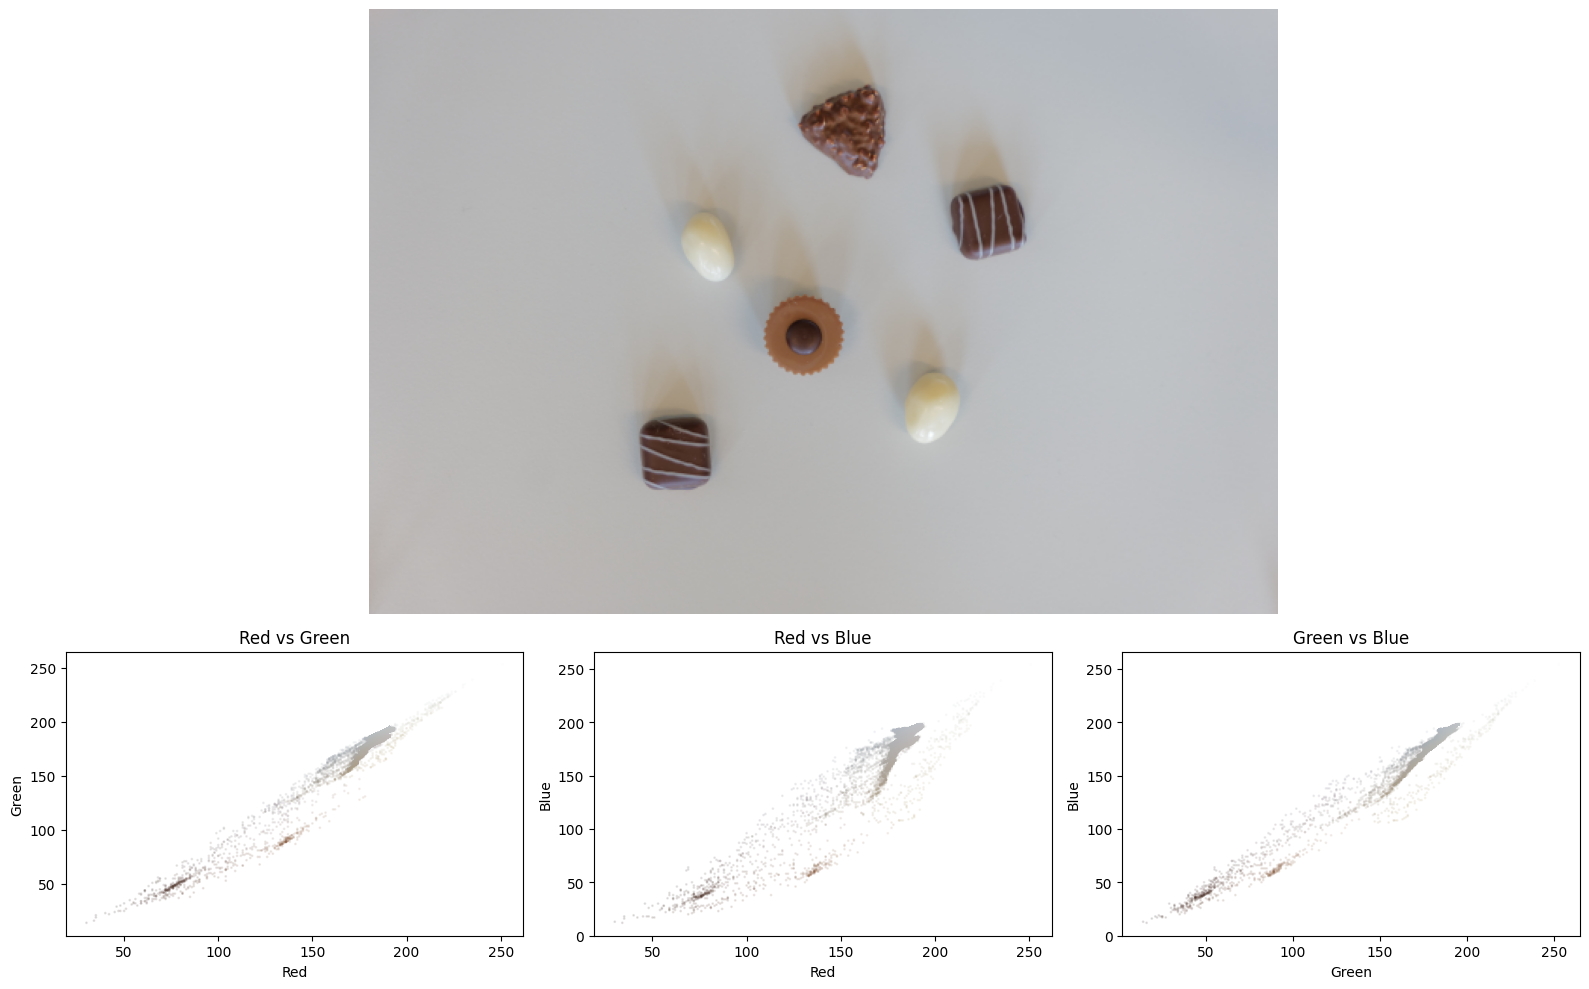

In [ ]:
label = train_labels[0]
lab1utils.plot_colors_histo(
    img = train_dict[label]['image'],
    func = lab1.extract_rgb_channels,
    labels = ["Red", "Green", "Blue"],
)

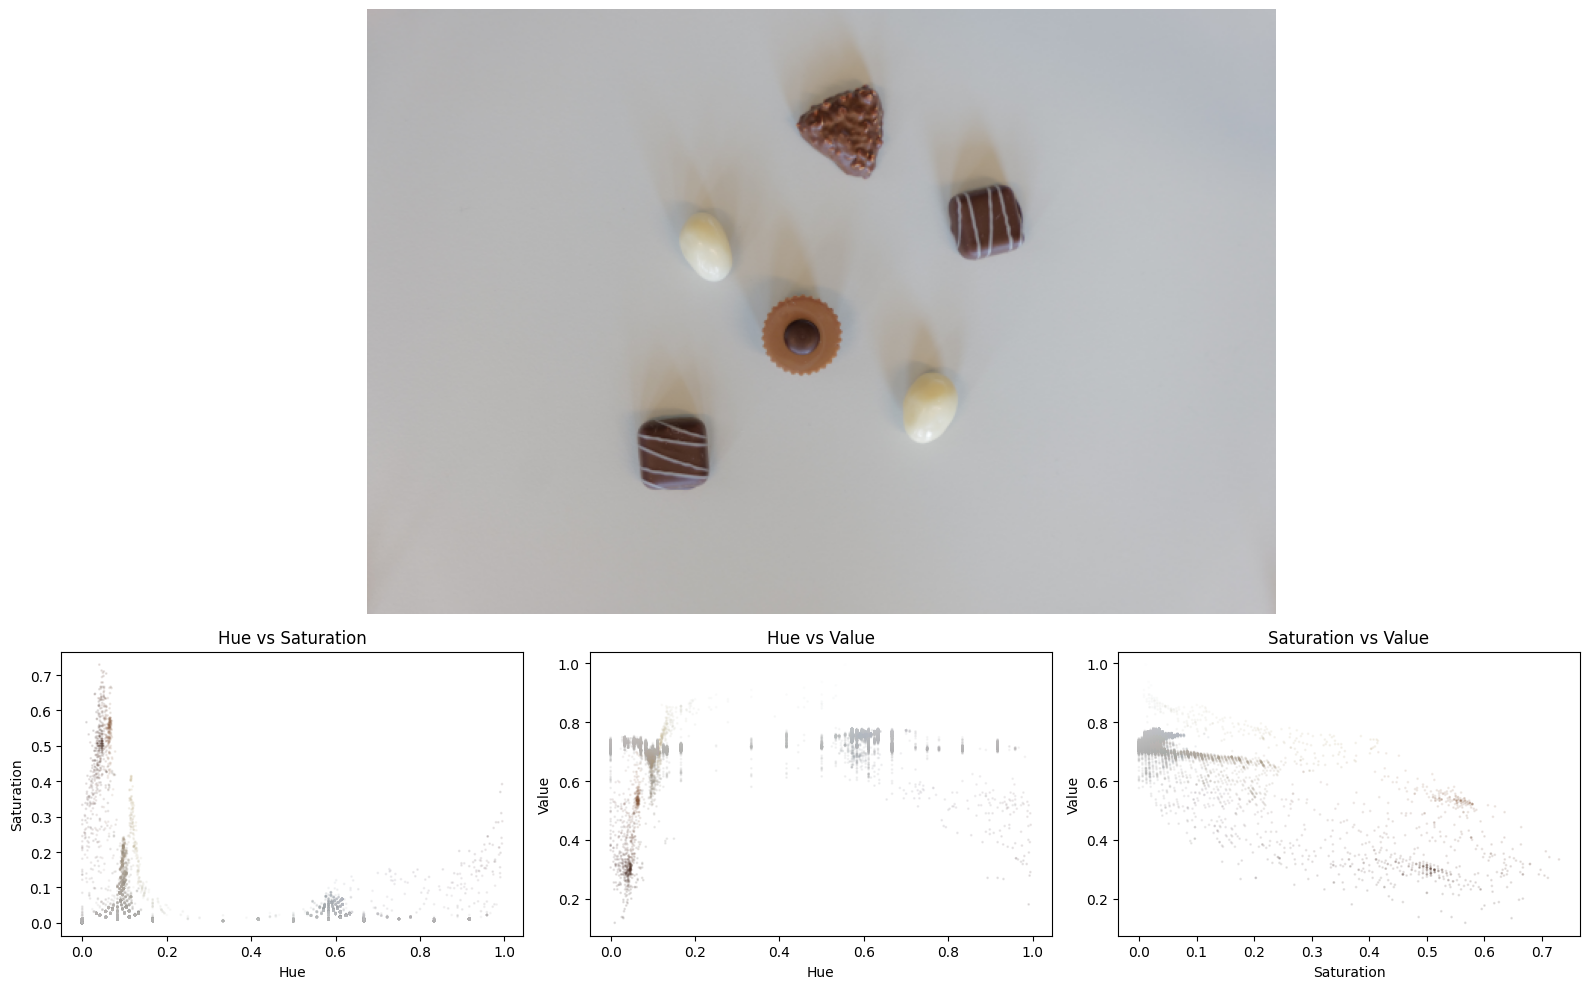

In [ ]:
label = train_labels[0]
lab1utils.plot_colors_histo(
    img = train_dict[label]['image'],
    func = lab1.extract_hsv_channels,
    labels = ["Hue", "Saturation", "Value"],
)

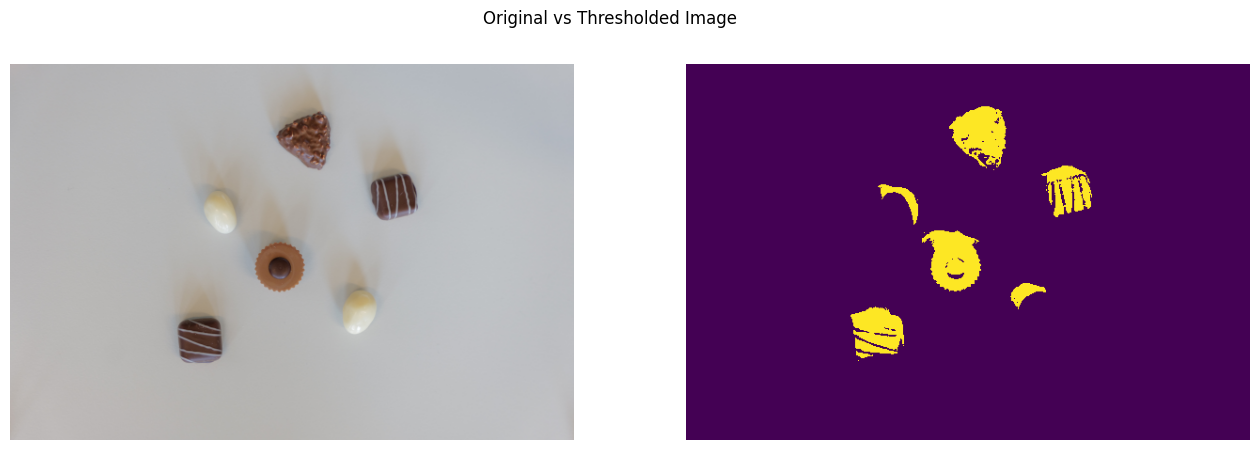

In [ ]:
### HSV Thresholding ###

# Added an "HSV" key to the dictionary to story the HSV thresholded images

for dict in train_dict.values():
    # Extract the image from the dictionary
    img = dict["image"]
    
    # Apply the HSV thresholding
    img_hsv = lab1.apply_hsv_threshold(img, H_min=0, H_max=0.2, S_min=0, S_max=1, V_min=0, V_max=0.65)
    
    # Add the new key-value pair to the dictionary
    dict["hsv_image"] = img_hsv

# Plot the original image and the thresholded image
label = train_labels[0]

# Compare the original image and the thresholded image
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['hsv_image'],
    title="Original vs Thresholded Image")
# Compare the original image and the thresholded image




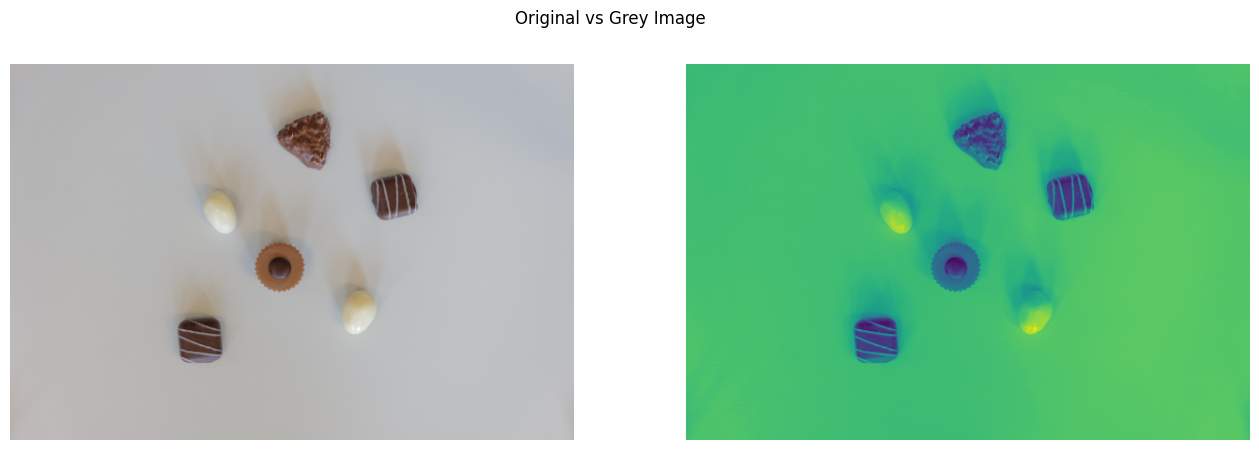

In [ ]:
# Convert the images to grayscale and add the grayscale images to the dictionary
for dict in train_dict.values():
    # Extract the image from the dictionary
    img = dict["image"]
    
    # Apply the HSV thresholding
    img_grey = np.uint8(pre.RGB2greyscale(img))
    # Add the new key-value pair to the dictionary
    dict["grey"] = img_grey

# Plot the original image and the thresholded image
label = train_labels[0]

# Compare the original image and the thresholded image
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['grey'],
    title="Original vs Grey Image")
# Compare the original image and the thresholded image



In [ ]:
# def _color_profile_filter(
#     img: np.ndarray,
#     color_profile: np.ndarray,
#     tolerance: float = 100.0,
#     return_mask: bool = False,
#     lab_space: bool = True
# ) -> np.ndarray:
#     """
#     Filter image using chocolate color profile.
    
#     Args:
#         img: Input image (H,W,3)
#         color_profile: Array of reference colors (n_colors, 3)
#         tolerance: Maximum color distance threshold
#         return_mask: If True, returns binary mask instead of filtered image
#         lab_space: Whether to use LAB color space (recommended)
    
#     Returns:
#         Filtered image or binary mask
#     """
#     if lab_space:
#         img_space = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#         profile_space = color_profile
#     else:
#         img_space = img
#         profile_space = color_profile
    
#     # Calculate distances to color profile
#     pixels = img_space.reshape(-1, 3)
#     distances = np.linalg.norm(pixels[:, None] - profile_space, axis=2)
#     min_dist = np.min(distances, axis=1)
#     print(f"Min distance: {min_dist}")
#     # Create mask
#     mask = (min_dist <= tolerance).reshape(img.shape[:2]).astype(np.uint8)
    
#     # Clean up mask
#     # kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
#     # mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
#     if return_mask:
#         return mask * 255
#     else:
#         result = img.copy()
#         result[mask == 0] = [255, 255, 255]  # Set background to white
#         return result


In [ ]:
# ### Apply Color Profile Filter to Train Images and Add to Dictionary ###

# # Apply the color profile filter to the train images
# for dict in train_dict.values():
#     # Extract the image from the dictionary
#     img = dict["image"]
    
#     # Apply the color profile filter
#     img_filtered = _color_profile_filter(
#         img,
#         color_profile=reference_color_profile,
#         tolerance=40.0,
#         return_mask=False,
#         lab_space=True
#     )
    
#     # Add the new key-value pair to the dictionary
#     dict["color_filtered"] = img_filtered



In [ ]:
# Plot the original image and the filtered image
label = train_labels[0]
# Compare the original image and the filtered image
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['color_filtered'],
    title="Original vs Filtered Image")

KeyError: 'color_filtered'

In [ ]:
### EXECUTE PIPELINE ON TRAIN IMAGES ###
t_lower_white = 1
t_upper_white = 70
t_lower_dark = 30
t_upper_dark = 115
aperture_size = 3
L2Gradient = False

# Make the parameters dynamic to tailor the shapes
kernel_size_white = 16
kernel_size_dark = 12
min_area_th = 10
min_obj_size = 20
connect = 2

# Dynamic Gaussian Blur 
blur_white = 1
blur_dark = 5

# Number of images to process
N = 10


# Apply the same preprocessing steps to the cropped images
for i, imgs in enumerate(train_images[:N]):
    # Extract the RGB channels
    R, G, B = lab1.extract_rgb_channels(imgs)
    H, S, V = lab1.extract_hsv_channels(imgs)
    
    # Update the dictionary to include the RGB and HSV channels
    train_dict[train_labels[i]].update({
        "R": R,  # Red channel
        "G": G,  # Green channel
        "B": B,  # Blue channel
        "H": H,  # Hue channel
        "S": S,  # Saturation channel
        "V": V   # Value channel
    })

    # Convert to grayscale
    img_grey = np.uint8(pre.RGB2greyscale(imgs))
    train_dict[train_labels[i]]["grey"] = img_grey

    # Add a bit of Gaussian blur to the images
    img_blury_white = cv2.GaussianBlur(img_grey, (blur_white, blur_white), 0)
    img_blury_dark = cv2.GaussianBlur(img_grey, (blur_dark, blur_dark), 0)

    # Apply Canny edge detection
    img_canny_white = cv2.Canny(img_blury_white, t_lower_white, t_upper_white, apertureSize=aperture_size, L2gradient=L2Gradient)
    img_canny_dark = cv2.Canny(img_blury_dark, t_lower_dark, t_upper_dark, apertureSize=aperture_size, L2gradient=L2Gradient)

    # Apply morphology
    img_morph_white = lab1.apply_morphology(img_canny_white, kernel_size=kernel_size_white, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    img_morph_dark = lab1.apply_morphology(img_canny_dark, kernel_size=kernel_size_dark, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)

    # Update the dictionary with internal `white` and `dark` dictionaries
    train_dict[train_labels[i]]["white"] = {
        "grey_blur": img_blury_white,
        "canny": img_canny_white,
        "canny_morph": img_morph_white
    }

    train_dict[train_labels[i]]["dark"] = {
        "grey_blur": img_blury_dark,
        "canny": img_canny_dark,
        "canny_morph": img_morph_dark
    }


In [ ]:
def plot_train_images_vs_filtered(train_dict, train_labels, pipeline_labels):
    """
    Plot processing pipeline steps for train images with consistent layout.
    
    Args:
        train_dict (dict): Dictionary containing train images and processed versions
        train_labels (list): List of train image labels to display
        pipeline_labels (list): Ordered list of processing steps to show as columns
                               (first should be 'image' for original)
    """
    ncols = len(pipeline_labels)
    nrows = len(train_labels)
    
    # Create figure - width scales with columns, height with rows
    fig, axes = plt.subplots(nrows, ncols, 
                           figsize=(2.5 * ncols, 2.5 * nrows))
    fig.suptitle("Image Processing Pipeline Steps", y=1.02, fontsize=14)
    
    # Handle case when there's only one row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, train_label in enumerate(train_labels):
        for col_idx, step_label in enumerate(pipeline_labels):
            ax = axes[row_idx, col_idx]
            
            # Special handling for original image (color)
            if step_label == 'image':
                img = train_dict[train_label].get('image')
                if img is not None:
                    ax.imshow(img)
                ax.set_title(f"Original\n{train_label}", fontsize=10)
            
            # Handling for processed images (grayscale)
            else:
                # Handle nested keys (e.g., 'white/canny')
                keys = step_label.split('/')
                img = train_dict[train_label]
                for key in keys:
                    img = img.get(key, None)
                    if img is None:
                        break
                
                if img is not None:
                    ax.imshow(img, cmap='gray')
                ax.set_title(f"{step_label}", fontsize=10)
            
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

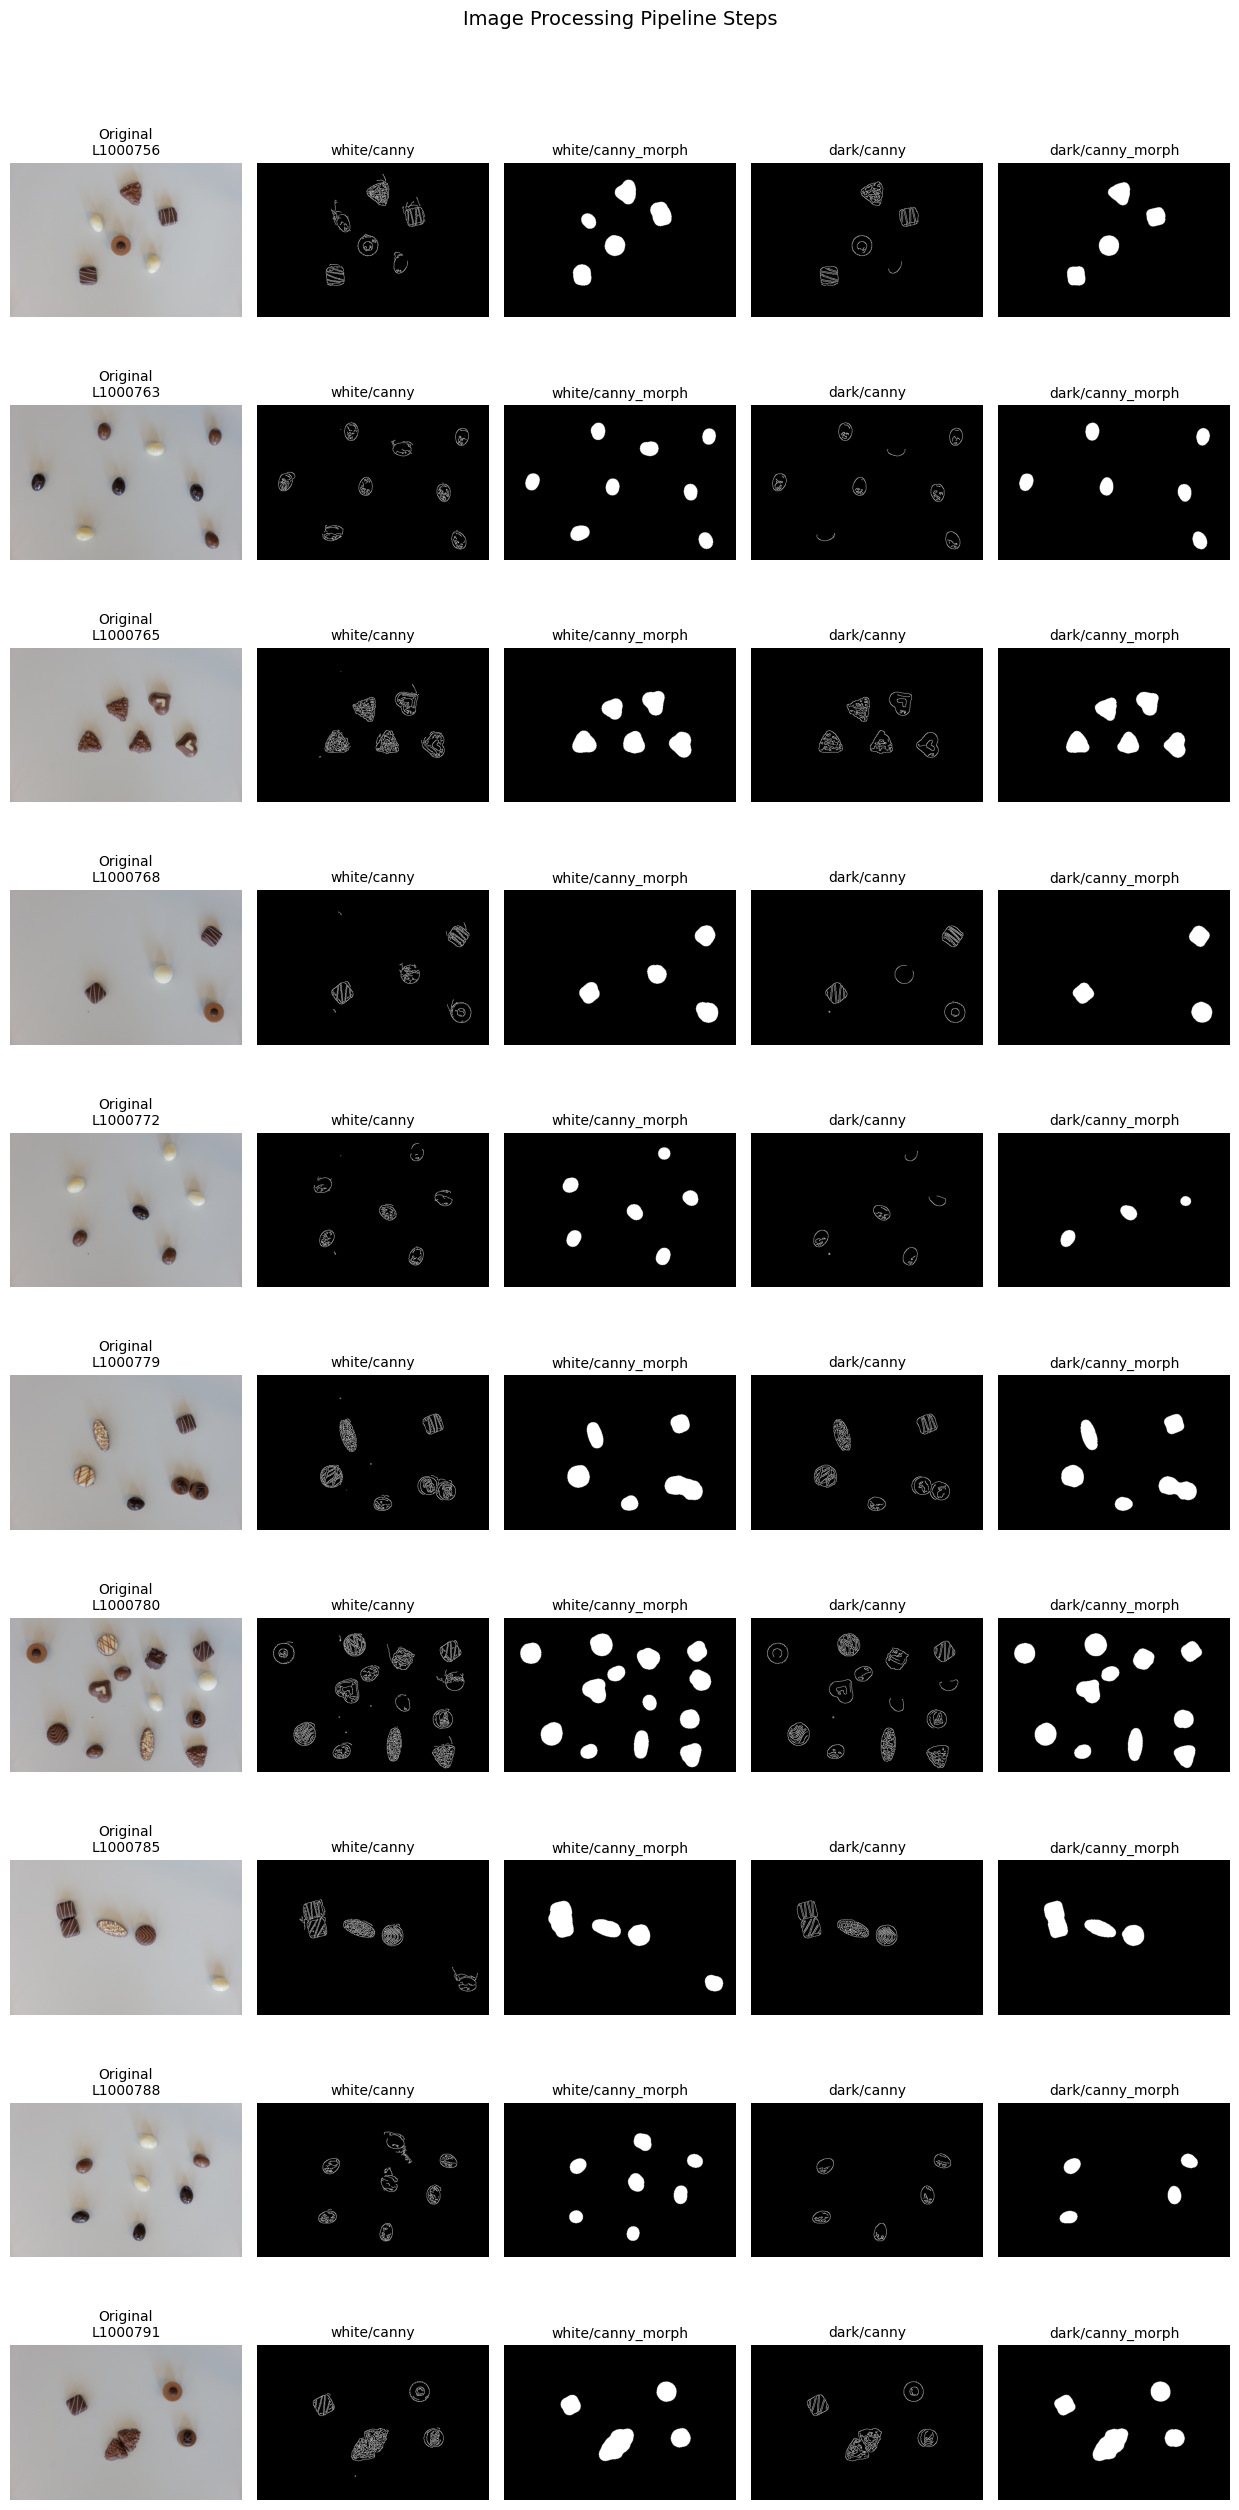

In [ ]:
# Define your processing steps
processing_steps = [
    'image',               # Column 1
    'white/canny',         # Column 2
    'white/canny_morph',   # Column 3
    'dark/canny',          # Column 4
    'dark/canny_morph'     # Column 5
]


# Call the function
plot_train_images_vs_filtered(
    train_dict=train_dict,
    train_labels=train_labels[:N],
    pipeline_labels=processing_steps
)

In [ ]:
### Blob Extraction ###

# For each of the canny_morph train images extract a bounding box of each of the blobs and store 
# binary image within each blob as an array of images in the train_dict under the name "blobs_binary"
# as well as an adjining array of the bounding boxes in the train_dict under the name "blobs_bounding_boxes"
# The bounding boxes are stored as a list of tuples with the coordinates (x, y, w, h) of each blob
# So the bounding boxes can be drawn on the original image

def extract_blobs(canny_morph_image: np.ndarray, plot: bool = False) -> tuple[list[tuple[int, int, int, int]], list[np.ndarray]]:
    """
    Extract blobs from a binary image and return their bounding boxes and binary images.
    
    Args:
        canny_morph_image: Binary image with blobs (2D numpy array).
        plot: Whether to plot the visualization image with bounding boxes and contours.
    
    Returns:
        List of tuples: Each tuple contains (x, y, w, h) of the bounding box for a blob.
        List of binary images: Each binary image corresponds to a blob (as 0/1 or True/False).
    """
    # Find contours
    contours, _ = cv2.findContours(canny_morph_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    bounding_boxes = []
    blobs_binary = []
    
    # Padding for the bounding boxes
    padding = 3

    # Create a copy of the image for visualization
    visualization_image = cv2.cvtColor(canny_morph_image, cv2.COLOR_GRAY2BGR)  # Convert to BGR for color visualization

    for contour in contours:
        if cv2.contourArea(contour) > 0:  # Filter out small areas
            x, y, w, h = cv2.boundingRect(contour)
            bounding_boxes.append((x, y, w, h))
            
            # Create a mask for the blob
            mask = np.zeros_like(canny_morph_image, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 255, -1)  # Fill the contour

            # Extract the blob using the mask
            blob = cv2.bitwise_and(canny_morph_image, canny_morph_image, mask=mask)
            # Crop the blob using the bounding box
            blob_cropped = blob[y - padding:y + h + padding, x - padding:x + w + padding]

            # Normalize the binary output to 0/1
            blob_cropped = (blob_cropped > 0).astype(np.uint8)  # Convert to 0/1 (or use `.astype(bool)` for True/False)
            blobs_binary.append(blob_cropped)

            # Draw the bounding box and contour on the visualization image
            cv2.rectangle(visualization_image, (x - padding, y - padding), (x + w + padding, y + h + padding), (255, 0, 0), 2)
            cv2.drawContours(visualization_image, [contour], -1, (0, 255, 0), 2)

    if plot:
        # Plot the visualization image with bounding boxes and contours
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(visualization_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for plotting
        plt.title("Contours and Bounding Boxes")
        plt.axis('off')
        plt.show()
    
    return bounding_boxes, blobs_binary

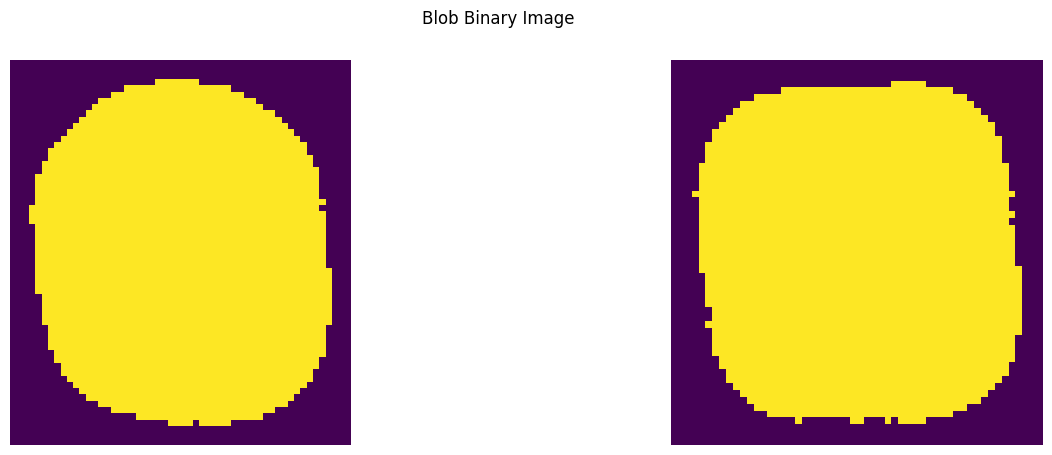

In [ ]:
### Apply the blob extraction to the train images ###

for i, dict in enumerate(list(train_dict.values())[:10]):
    # Extract the images from the nested dictionaries
    img_white = dict["white"]["canny_morph"]
    img_dark = dict["dark"]["canny_morph"]

    # Extract blobs from the canny_morph images
    blobs_bounding_boxes_white, blobs_binary_white = extract_blobs(img_white)
    blobs_bounding_boxes_dark, blobs_binary_dark = extract_blobs(img_dark)
    
    # Add the blobs and bounding boxes to the respective nested dictionaries
    dict["white"].update({
        "blobs_bounding_boxes": blobs_bounding_boxes_white,
        "blobs_binary": blobs_binary_white
    })
    dict["dark"].update({
        "blobs_bounding_boxes": blobs_bounding_boxes_dark,
        "blobs_binary": blobs_binary_dark
    })

# Plot a blob from the first image as binary image
label = train_labels[0]
# Compare the original image and the filtered image
pre.compare_2_images(
    image1=train_dict[label]['white']['blobs_binary'][0],
    image2=train_dict[label]['dark']['blobs_binary'][0],
    title="Blob Binary Image")

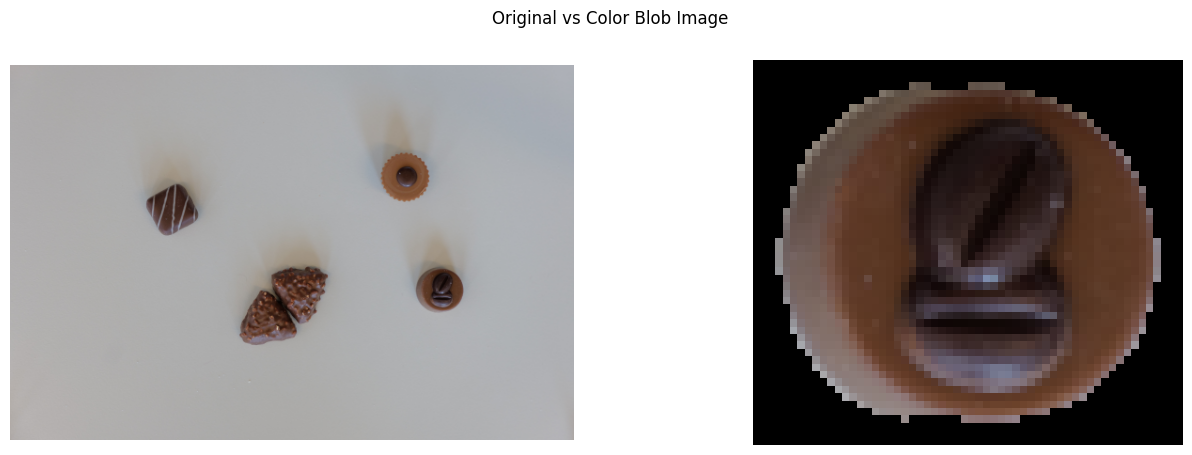

In [ ]:
### Extract Color and Greyscale Images from the Blobs ###
# For each of the blobs extract the color image within the blob and store it in the train_dict

# First create a function to extract the color and greyscale images from the blobs

def extract_color_and_greyscale_from_blobs(
    img: np.ndarray,
    blobs_bounding_boxes: list[tuple[int, int, int, int]],
    blobs_binary: list[np.ndarray],
    padding: int = 3
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """
    Extract color and grayscale images from the blobs in the original image.
    
    Args:
        img: Original image (H,W,3).
        blobs_bounding_boxes: List of tuples with bounding box coordinates (x, y, w, h).
        blobs_binary: List of binary images for each blob.
        padding: Padding to add around the bounding boxes.
    
    Returns:
        List of color images and list of grayscale images for each blob.
    """
    color_images = []
    gray_images = []

    for i, (x, y, w, h) in enumerate(blobs_bounding_boxes):
        # Extract the color image using the bounding box
        color_blob = img[y - padding:y + h + padding, x - padding:x + w + padding]

        # Apply the binary mask to the color image
        mask = blobs_binary[i]
        color_blob = cv2.bitwise_and(color_blob, color_blob, mask=mask)


        color_images.append(color_blob)

        # Convert the color blob to grayscale
        gray_blob = cv2.cvtColor(color_blob, cv2.COLOR_RGB2GRAY)
        gray_images.append(gray_blob)

    return color_images, gray_images

# Now apply the function to the first image in the train_dict
label = train_labels[9]
img = train_dict[label]['image']
blobs_bounding_boxes = train_dict[label]['dark']['blobs_bounding_boxes']
blobs_binary = train_dict[label]['dark']['blobs_binary']
# Extract color and grayscale images from the blobs
color_images, gray_images = extract_color_and_greyscale_from_blobs(
    img=img,
    blobs_bounding_boxes=blobs_bounding_boxes,
    blobs_binary=blobs_binary,
    padding=3
)

# Plot the original image and the first extracted color blob
pre.compare_2_images(
    image1=img,
    image2=color_images[0],
    title="Original vs Color Blob Image"
)


In [ ]:
### Add the color and grayscale blobs to the train_dict ###

for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    img = dict["image"]
    blobs_bounding_boxes_white = dict["white"]["blobs_bounding_boxes"]
    blobs_binary_white = dict["white"]["blobs_binary"]
    blobs_bounding_boxes_dark = dict["dark"]["blobs_bounding_boxes"]
    blobs_binary_dark = dict["dark"]["blobs_binary"]

    # Extract color and grayscale images from the blobs
    color_images_white, gray_images_white = extract_color_and_greyscale_from_blobs(
        img=img,
        blobs_bounding_boxes=blobs_bounding_boxes_white,
        blobs_binary=blobs_binary_white,
        padding=3
    )
    color_images_dark, gray_images_dark = extract_color_and_greyscale_from_blobs(
        img=img,
        blobs_bounding_boxes=blobs_bounding_boxes_dark,
        blobs_binary=blobs_binary_dark,
        padding=3
    )

    # Add the color and grayscale images to the respective nested dictionaries
    dict["white"].update({
        "color_images_cropped": color_images_white,
        "gray_images_cropped": gray_images_white
    })
    dict["dark"].update({
        "color_images_cropped": color_images_dark,
        "gray_images_cropped": gray_images_dark
    })



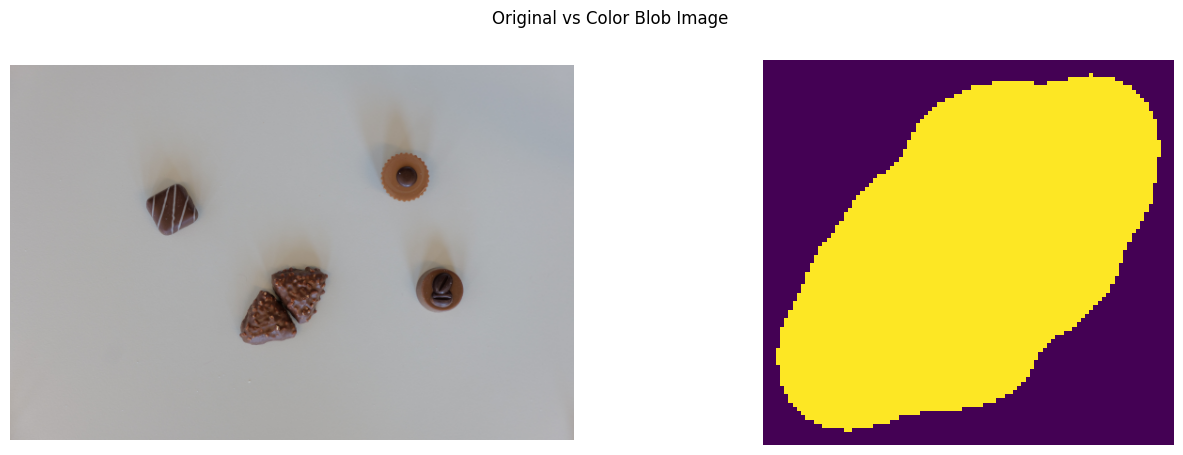

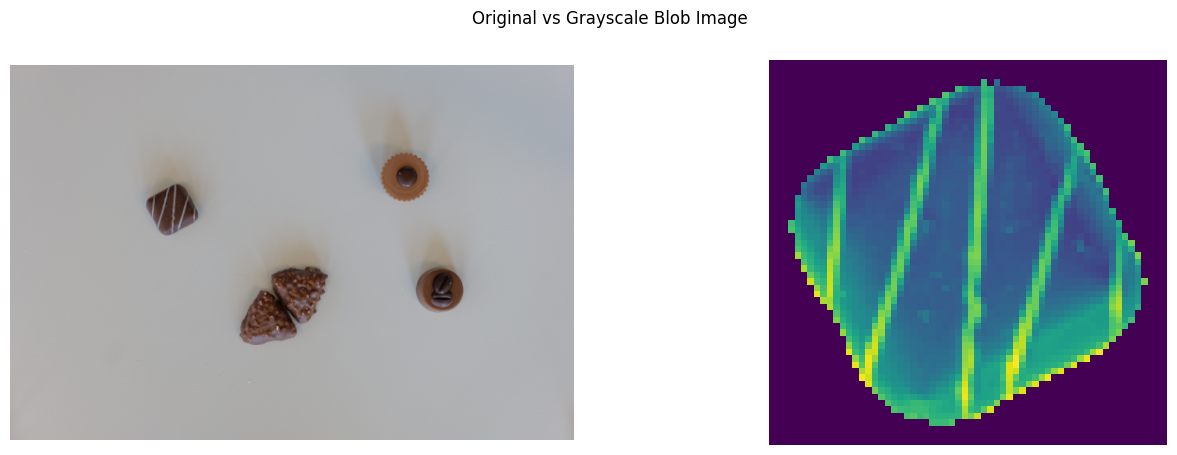

In [ ]:
# Plot the first color and grayscale blob from the first image
label = train_labels[9]
# Compare the original image and the color blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['white']['blobs_binary'][0],
    title="Original vs Color Blob Image"
)
# Compare the original image and the grayscale blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['dark']['gray_images_cropped'][2],
    title="Original vs Grayscale Blob Image"
)

In [ ]:
### Do canny edge detection on the grayscale blobs and Add to the Dictionary ###

# For each of the grayscale blobs apply canny edge detection and store the images in the train_dict
for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    gray_images_cropped_white = dict["white"]["gray_images_cropped"]
    gray_images_cropped_dark = dict["dark"]["gray_images_cropped"]

    # Apply Canny edge detection to the grayscale blobs
    canny_blobs_white = []
    canny_blobs_dark = []

    for img in gray_images_cropped_white:
        img_canny = cv2.Canny(img, t_lower_white, t_upper_white, apertureSize=aperture_size, L2gradient=L2Gradient)
        canny_blobs_white.append(img_canny)

    for img in gray_images_cropped_dark:
        img_canny = cv2.Canny(img, t_lower_dark, t_upper_dark, apertureSize=aperture_size, L2gradient=L2Gradient)
        canny_blobs_dark.append(img_canny)

    # Add the canny images to the respective nested dictionaries
    dict["white"].update({
        "canny_cropped": canny_blobs_white
    })
    dict["dark"].update({
        "canny_cropped": canny_blobs_dark
    })



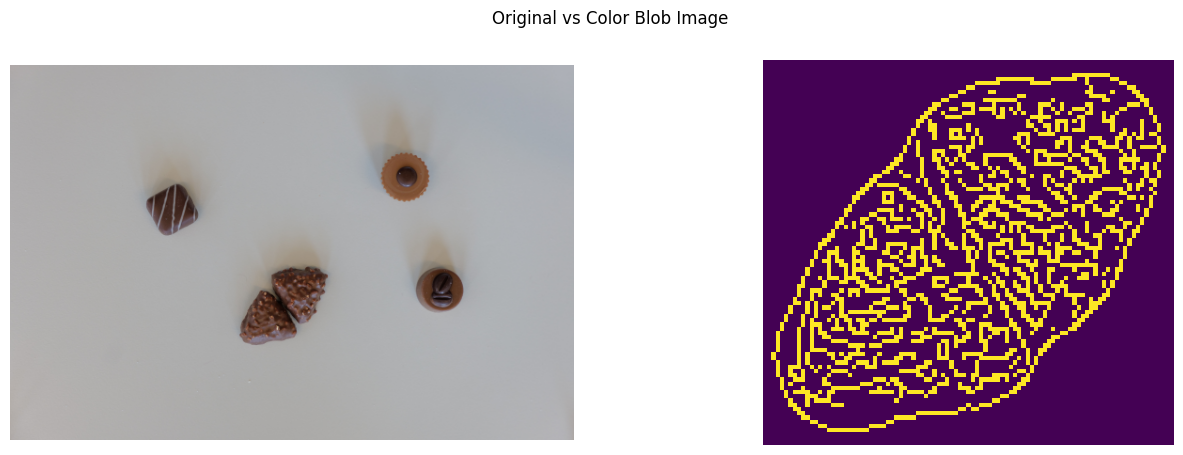

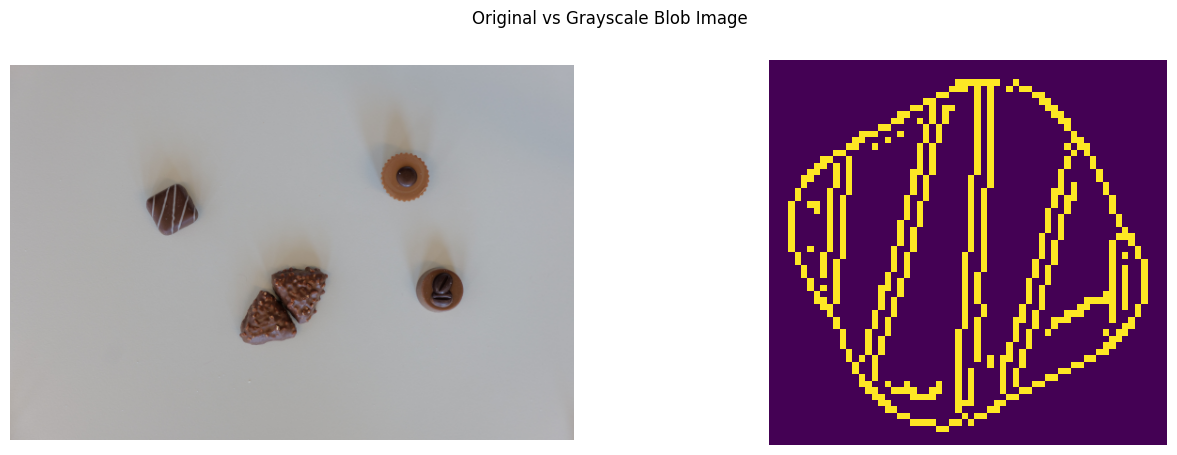

In [ ]:
# Plot the first color and canny blob from the first image
label = train_labels[9]
# Compare the original image and the color blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['white']['canny_cropped'][0],
    title="Original vs Color Blob Image"
)
# Compare the original image and the grayscale blob
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['dark']['canny_cropped'][2],
    title="Original vs Grayscale Blob Image"
)

In [ ]:
### Add th contours to the Dictionary ###
# For each of the canny blobs apply contours and store the images in the train_dict
for i, dict in enumerate(list(train_dict.values())[:N]):
    # Extract the images from the nested dictionaries
    blobs_white = dict["white"]["blobs_binary"]
    blobs_dark = dict["dark"]["blobs_binary"]

    # Apply contours to the canny blobs
    contours_blobs_white = []
    contours_blobs_dark = []

    for img in blobs_white:
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, H, W)
        contours = lab2.find_contour(img)  
        contours_blobs_white.append(contours)

    for img in blobs_dark:
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, H, W)
        contours = lab2.find_contour(img)
        contours_blobs_dark.append(contours)

    # Add the contours to the respective nested dictionaries
    dict["white"].update({
        "contours": contours_blobs_white
    })
    dict["dark"].update({
        "contours": contours_blobs_dark
    })

In [ ]:
### Add Shape Features to the Dictionary ###
# For each of the contours calculate the shape features and store them in the train_dict
for i, data in enumerate(list(train_dict.values())[:N]):  # Rename 'dict' to 'data' to avoid shadowing the built-in dict type
    # Extract the contours from the nested dictionaries
    contours_blobs_white = data["white"]["contours"]
    contours_blobs_dark = data["dark"]["contours"]

    # Define the shape feature names
    features = ["area", "perimeter", "compactness", "rectangularity", "extent"]

    # Initialize dictionaries to store individual shape features
    shape_features_white = {feature: [] for feature in features}
    shape_features_dark = {feature: [] for feature in features}

    # Initialize arrays to store all shape features
    shape_features_array_white = []
    shape_features_array_dark = []

    # Compute shape features for white contours
    for contour in contours_blobs_white:
        shape_features = compute_shape_features(np.array(contour))  # Compute shape features for the contour
        shape_features_array_white.append(shape_features)  # Store the full array of shape features
        for i, feature in enumerate(features):
            shape_features_white[feature].append(shape_features[i])  # Add the i-th feature to the corresponding list

    # Compute shape features for dark contours
    for contour in contours_blobs_dark:
        shape_features = compute_shape_features(np.array(contour))  # Compute shape features for the contour
        shape_features_array_dark.append(shape_features)  # Store the full array of shape features
        for i, feature in enumerate(features):
            shape_features_dark[feature].append(shape_features[i])  # Add the i-th feature to the corresponding list

    # Add the shape features to the respective nested dictionaries
    data["white"].update(shape_features_white)
    data["white"]["shape_features"] = np.array(shape_features_array_white)  # Store the full array of shape features
    data["dark"].update(shape_features_dark)
    data["dark"]["shape_features"] = np.array(shape_features_array_dark)  # Store the full array of shape features

In [ ]:
### Print the Available Data in Train Dict ###
# Print the keys in the train_dict
print('-----Train Dictionary Keys-----')
keys = train_dict.keys()
print(f"Keys in train_dict: {', '.join(keys)}")
keys = train_dict[train_labels[0]].keys()
print(f"Keys in train_dict 1st Layer: {', '.join(keys)}")
keys = train_dict[train_labels[0]]['white'].keys()
print(f"Keys in train_dict 2nd Layer (white): {', '.join(keys)}")

# Print the keys of the reference cropped images dictionary
print('-----Cropped Reference Dictionary Keys-----')
keys = cropped_reference_dict.keys()
print(f"Keys in cropped_reference_dict: {', '.join(keys)}")
keys = cropped_reference_dict[reference_labels[0]].keys()
print(f"Keys in cropped_reference_dict 1st Layer: {', '.join(keys)}")



-----Train Dictionary Keys-----
Keys in train_dict: L1000756, L1000763, L1000765, L1000768, L1000772, L1000779, L1000780, L1000785, L1000788, L1000791, L1000792, L1000793, L1000797, L1000799, L1000802, L1000804, L1000808, L1000810, L1000812, L1000815, L1000817, L1000826, L1000827, L1000828, L1000831, L1000843, L1000844, L1000850, L1000851, L1000854, L1000859, L1000866, L1000870, L1000872, L1000875, L1000876, L1000880, L1000882, L1000885, L1000888, L1000890, L1000894, L1000896, L1000899, L1000900, L1000903, L1000909, L1000910, L1000914, L1000916, L1000923, L1000926, L1000928, L1000930, L1000932, L1000939, L1000941, L1000946, L1000951, L1000952, L1000957, L1000963, L1000964, L1000965, L1000971, L1000972, L1000974, L1000977, L1000979, L1000981, L1000987, L1000989, L1000992, L1000993, L1001000, L1010004, L1010008, L1010009, L1010012, L1010014, L1010015, L1010019, L1010022, L1010026, L1010029, L1010031, L1010032, L1010035, L1010041, L1010045
Keys in train_dict 1st Layer: image, R, G, B, H, 

# KNN Classifier #

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from collections import Counter
from collections import defaultdict

class ChocolateClassifier:
    def __init__(self, reference_labels):
        self.reference_labels = reference_labels
        self.feature_options = ['area', 'perimeter', 'compactness', 'rectangularity', 'extent']
    
    def prepare_data(self, cropped_reference_dict, train_dict, train_image_key, eval_params):
        """Prepare training and test data with selected features"""
        # Validate requested features
        if not all(param in self.feature_options for param in eval_params):
            raise ValueError(f"Invalid feature(s) in eval_params. Options are: {self.feature_options}")
        
        print("\n=== REFERENCE CHOCOLATES FEATURE VALUES ===")
        print(f"{'Chocolate Type':<20}", "\t".join([f"{param:<12}" for param in eval_params]))
        
        # Extract reference features and labels
        X_ref, y_ref = [], []
        for chocolate_type, data in cropped_reference_dict.items():
            # Attempt to format the features (this will still fail if the issue persists)
            try:
                # Extract the first value from the list if the feature is a list with length 1
                features = [
                    param[0] if isinstance(param, list) and len(param) == 1 else param
                    for param in [data[param] for param in eval_params]
                ]
                
                print(f"{chocolate_type:<20}", "\t".join([f"{val:<12.4f}" for val in features]))
                
                X_ref.append(features)
                y_ref.append(chocolate_type)
            except KeyError as e:
                raise KeyError(f"Missing feature {str(e)} in reference data for {chocolate_type}")
        X_test = []
        try:
            train_data = train_dict[train_image_key]['white']
            num_chocolates = len(train_data['area'])
            print("\n=== TRAIN CHOCOLATES FEATURE VALUES ===")
            for i in range(num_chocolates):
                try:
                    features = [train_data[param][i] for param in eval_params]
                    print(f"{f'Choc {i+1}':<12}", "\t".join([f"{val:<12.4f}" for val in features]))
                    
                    X_test.append(features)
                except (KeyError, IndexError) as e:
                    raise KeyError(f"Missing feature {str(e)} in test image {train_image_key}")
        
        except KeyError as e:
            raise KeyError(f"Invalid train image key or missing white chocolates: {str(e)}")
        
        return np.squeeze(np.array(X_ref)), np.squeeze(np.array(y_ref)), np.squeeze(np.array(X_test))
    
    def classify_chocolates(self, cropped_reference_dict, train_dict, train_image_key, 
                          eval_params, n_neighbors=5):
        """Main classification function"""
        # Prepare data
        X_train, y_train, X_test = self.prepare_data(
            cropped_reference_dict, train_dict, train_image_key, eval_params)
        
        # Standardize and classify
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print("Class distribution in y_train:")
        print(Counter(y_train))
        
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train_scaled, y_train)
        
        predictions = knn.predict(X_test_scaled)
        probabilities = knn.predict_proba(X_test_scaled)
        print("Predictions:", predictions)
        print("Probabilities:", probabilities)

        distances, indices = knn.kneighbors(X_test_scaled)
        print("Distances to nearest neighbors:")
        print(distances)
        
        # Count predictions
        counts = defaultdict(int)
        for label in self.reference_labels:
            counts[label] = 0
        for pred in predictions:
            counts[pred] += 1
        
        # Prepare results
        results = {
            'predictions': predictions,
            'probabilities': probabilities,
            'counts': counts,
            'classifier': knn,
            'scaler': scaler
        }
        
        self.print_results(train_image_key, eval_params, results)
        return results
    
    def print_results(self, image_key, eval_params, results):
        """Print formatted results"""
        print(f"\nResults for image {image_key} using features {eval_params}:")
        print("-" * 50)
        print("Chocolate Counts:")
        for label, count in results['counts'].items():
            print(f"{label:<20}: {count}")
        
        print("\nIndividual Predictions:")
        for i, (pred, prob) in enumerate(zip(results['predictions'], results['probabilities'])):
            print(f"Chocolate {i+1:>2}: {pred:<20} (confidence: {max(prob)*100:.1f}%)")
        
        # Format submission results
        submission = [int(image_key[1:])] + list(results['counts'].values())
        print("\nSubmission Format:")
        print(submission)

# reference_labels = ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 
#                     'Jelly_Black', 'Jelly_Milk', 'Jelly_White', 'Noblesse',
#                     'Noir_authentique', 'Passion_au_lait', 'Stracciatella',
#                     'Tentation_noir', 'Triangolo']

classifier = ChocolateClassifier(reference_labels)
label = train_labels[0]
# Example classification with feature value printing
results = classifier.classify_chocolates(
    cropped_reference_dict=cropped_reference_dict,
    train_dict=train_dict,
    train_image_key=label,  # Replace with your image key
    eval_params=['compactness',  'perimeter'],  # Features to use
    n_neighbors=1
)

# Plot Train image



=== REFERENCE CHOCOLATES FEATURE VALUES ===
Chocolate Type       compactness 	perimeter   
Amandina             1.4541      	215.9239    
Arabia               1.1296      	156.9533    
Comtesse             1.1330      	161.4386    
Creme_brulee         1.1393      	188.5097    
Jelly_Black          1.1509      	133.2965    
Jelly_Milk           1.1562      	127.0538    
Jelly_White          1.1585      	138.1249    
Noblesse             1.1125      	170.8528    
Noir_authentique     1.1220      	180.5097    
Passion_au_lait      1.2442      	203.3797    
Stracciatella        1.2320      	176.9533    
Tentation_noir       1.2937      	188.1665    
Triangolo            1.3078      	194.1665    

=== TRAIN CHOCOLATES FEATURE VALUES ===
Choc 1       1.1568      	173.7817    
Choc 2       1.1421      	175.9239    
Choc 3       1.1609      	127.5391    
Choc 4       1.2123      	197.5807    
Choc 5       1.2302      	193.1371    
Class distribution in y_train:
Counter({np.str_('Amandina'): 

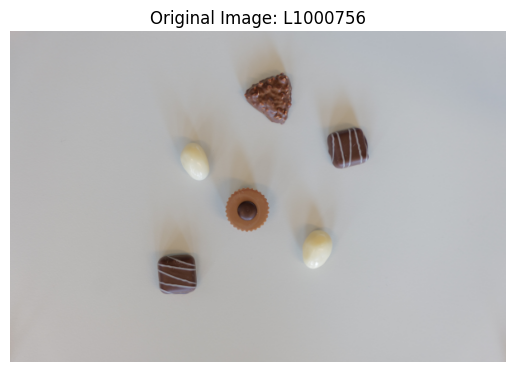

In [ ]:
# Show the original image
train_image = train_dict[label]['image']
plt.imshow(train_image)
plt.title(f"Original Image: {label}")
plt.axis('off')
plt.show()

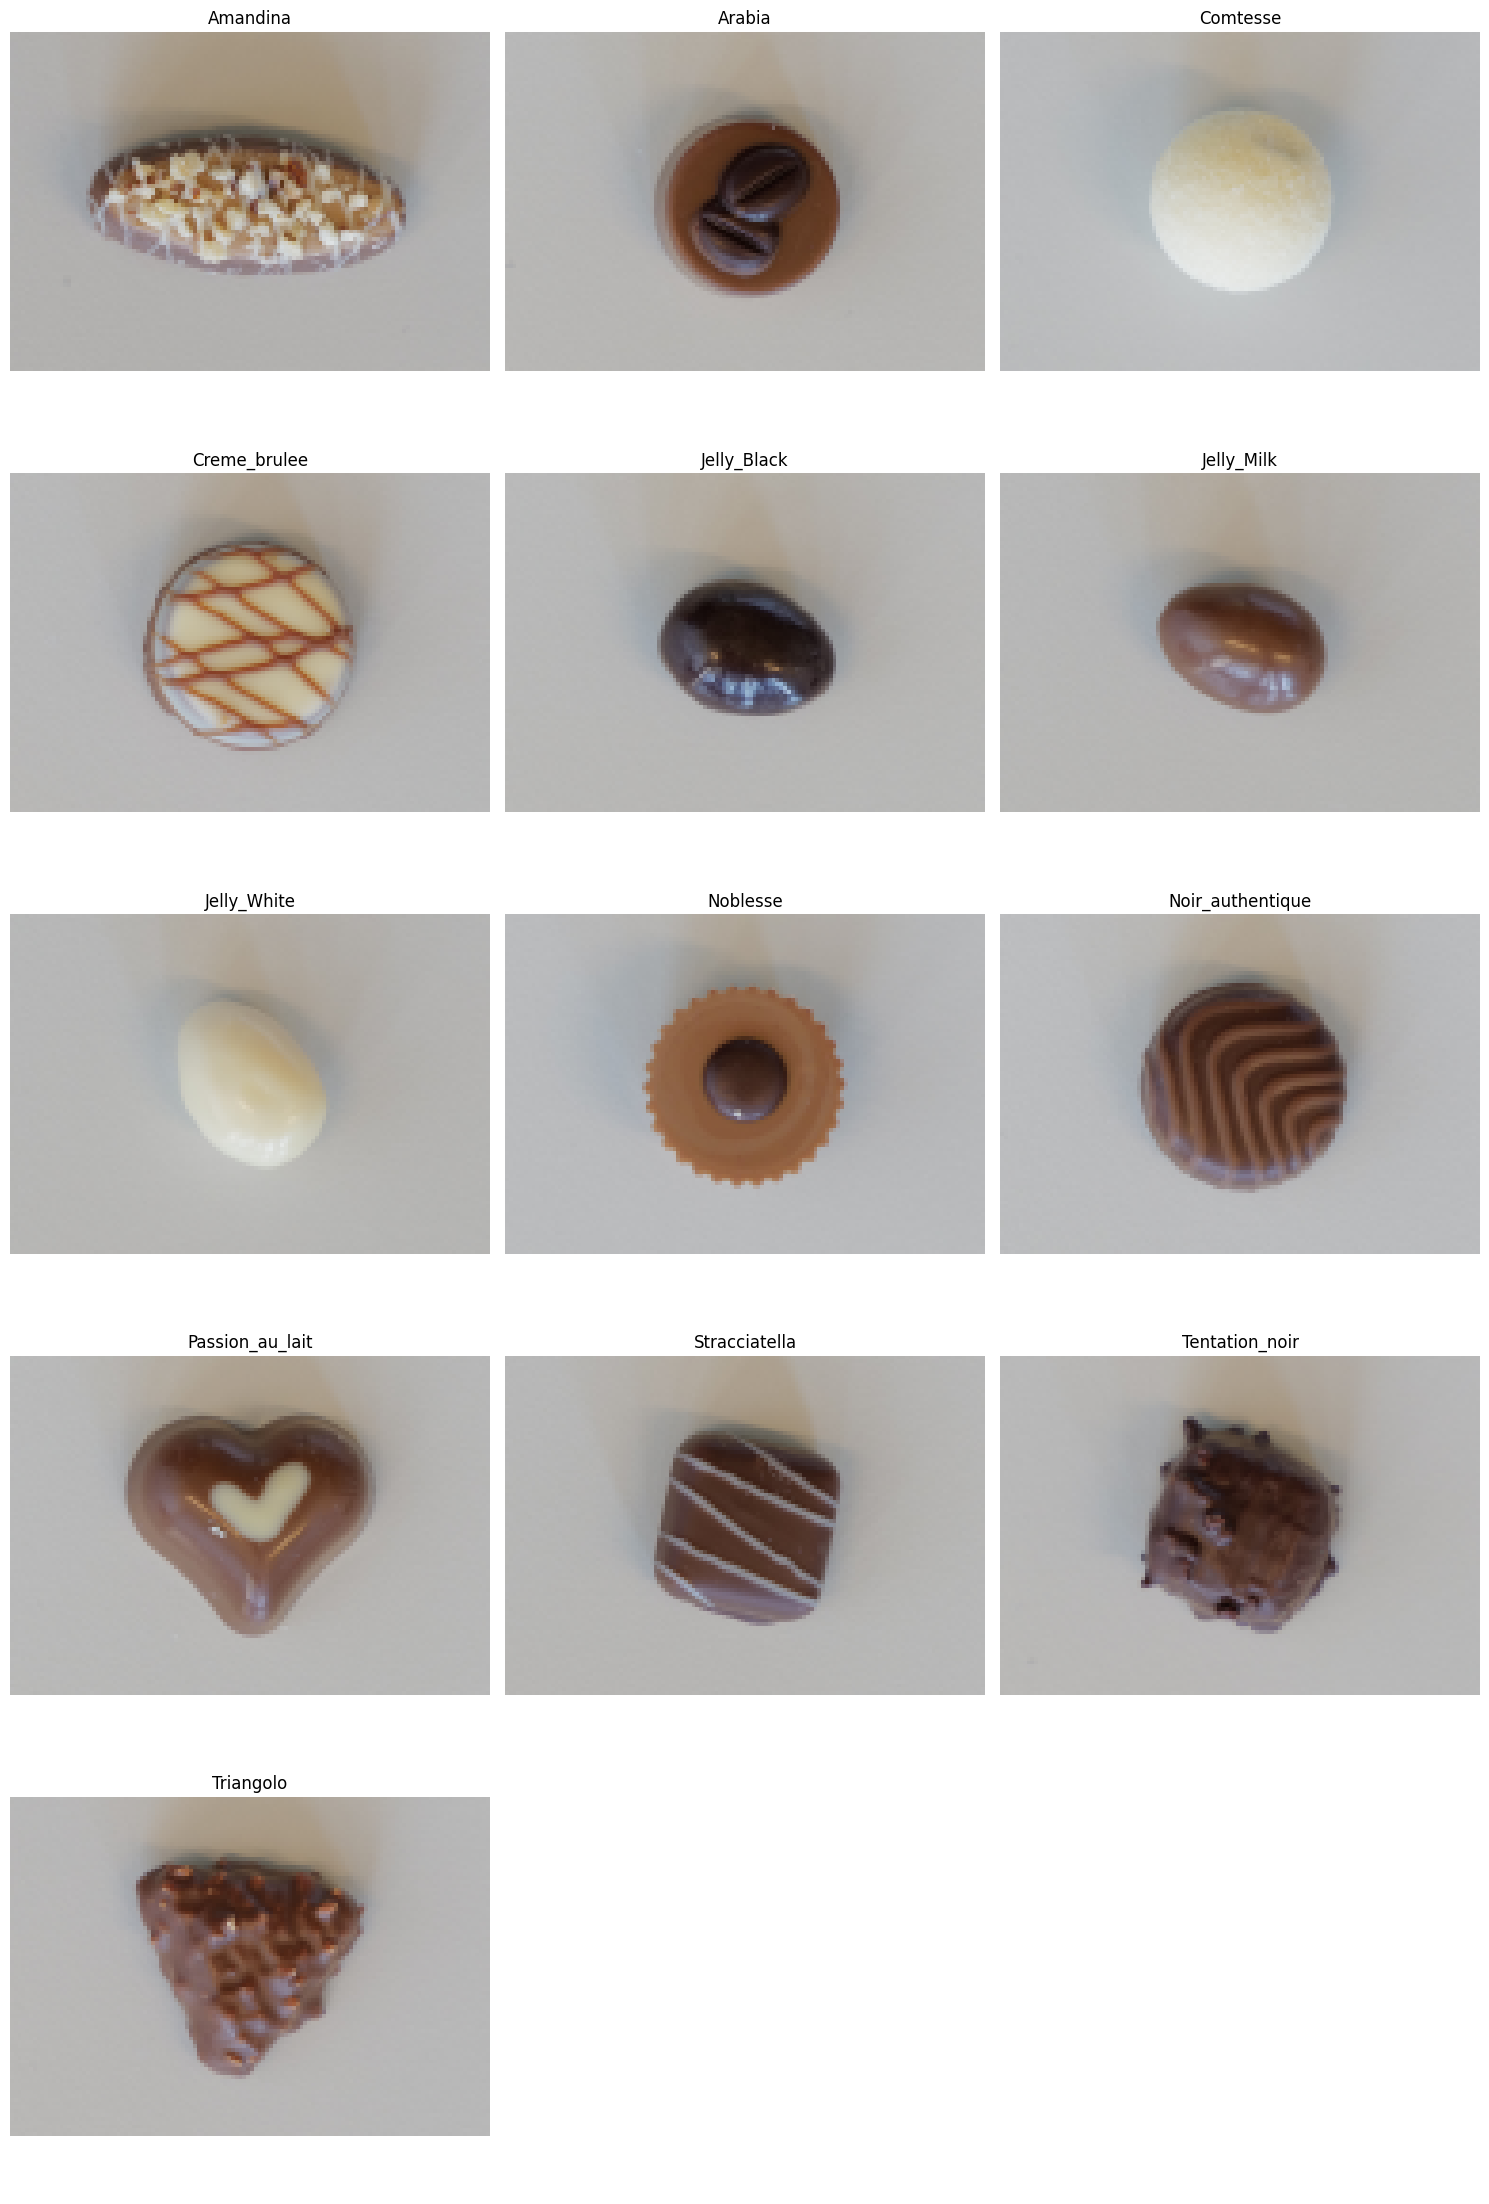

In [ ]:
# Show the refrence Images
pre.plot_reference_images(
    images=cropped_refrence_images,
    labels=reference_labels
)

# --- EXTRA STUFF --- #

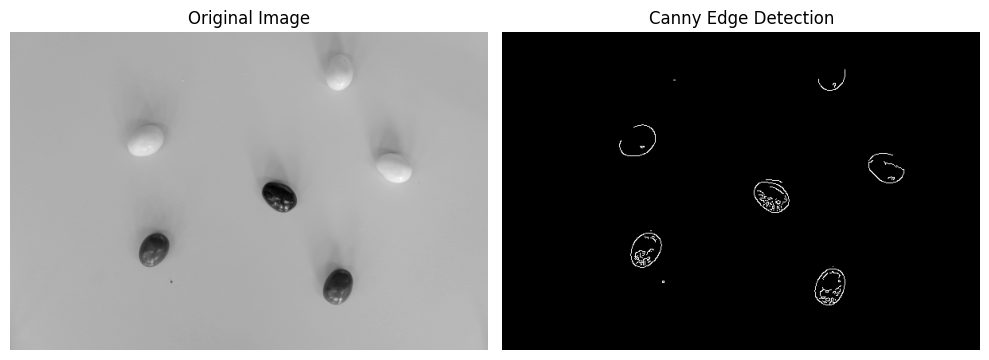

In [ ]:
# Load image
label = train_labels[4]
image = np.uint8(train_dict[label]['grey'])

t_lower = 40
t_upper = 85 
aperture_size = 3 
L2Gradient = False

cv_canny = cv2.Canny(image, t_lower, t_upper, apertureSize=aperture_size, L2gradient=L2Gradient)

# Display results
# Display results using matplotlib
plt.figure(figsize=(10, 5))  # Set the figure size

# Plot the original image
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1
plt.imshow(image, cmap='gray')  # Display the image in grayscale
plt.title('Original Image')
plt.axis('off')  # Turn off axis

# Plot the Canny edge-detected image
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2
plt.imshow(cv_canny, cmap='gray')  # Display the Canny result in grayscale
plt.title('Canny Edge Detection')
plt.axis('off')  # Turn off axis

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

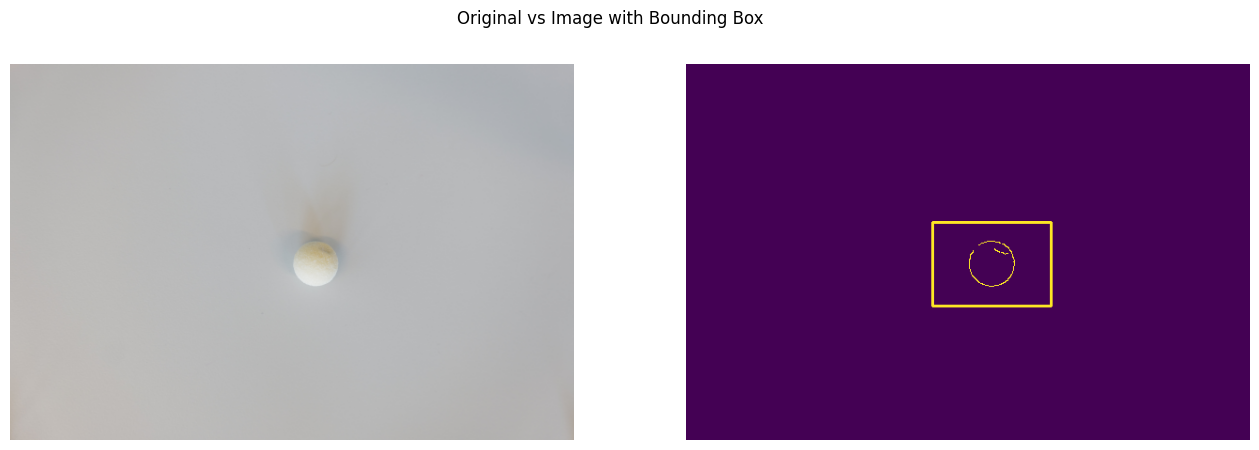

In [ ]:
# Plot the original image and the image with the bounding box
label = reference_labels[2]
# Compare the original image and the image with the bounding box
pre.compare_2_images(
    image1=reference_dict[label]['image'],
    image2=reference_dict[label]['image_with_box'],
    title="Original vs Image with Bounding Box")

In [ ]:
# # Plot the original image and the background removed image
# k = 8
# # Compare the original image and the background removed image
# pre.compare_2_images(
#     image1=reference_images_raw[k],
#     image2=reference_images_nobg[k],
#     title="Original vs Background Removed Image")

In [ ]:
# Canny Edge Detection Params
t_lower = 40
t_upper = 85 
aperture_size = 3 
L2Gradient = False

#Morphology Params
kernel_size=12
min_area_th=1
min_obj_size=100
connect=1

c:\Users\sunde\Desktop\Local_Repos\ImageAnalysisAndPatternRecognitionGroupWork\project\src\lab1.py:275: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  img_morph = remove_small_holes(img_morph, area_threshold=min_area_th, connectivity=connect, out=None)


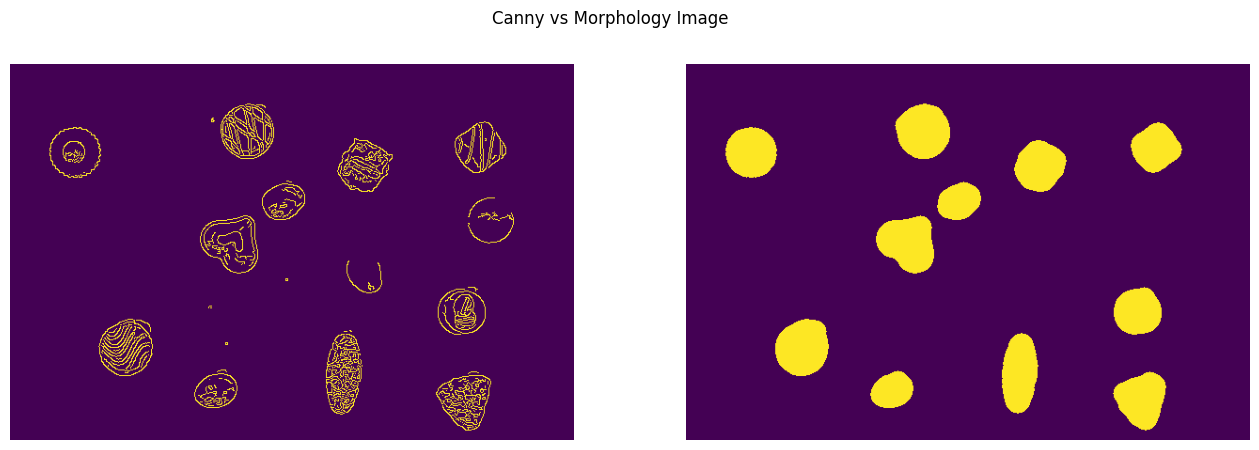

In [ ]:
# Apply Canny edge detection to the images and add the Canny images to the dictionary
for dict in train_dict.values():
    # Extract the image from the dictionary
    img = np.uint8(dict["grey"])
    
    # Apply the Canny edge detection
    img_canny = cv2.Canny(img, t_lower, t_upper, apertureSize=aperture_size, L2gradient=L2Gradient)
    
    # Add the new key-value pair to the dictionary
    dict["canny"] = img_canny

# Apply morphology to the Canny edge-detected image
for dict in train_dict.values():
    # Extract the image from the dictionary
    img = dict["canny"]
    
    # Apply the morphology
    img_morph = lab1.apply_morphology(img, kernel_size=kernel_size, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
    
    # Add the new key-value pair to the dictionary
    dict["canny_morph"] = img_morph

# Plot the original image and the thresholded image
label = train_labels[6]
# Compare the original image and the thresholded image
pre.compare_2_images(
    image1=train_dict[label]['canny'],
    image2=train_dict[label]['canny_morph'],
    title="Canny vs Morphology Image")


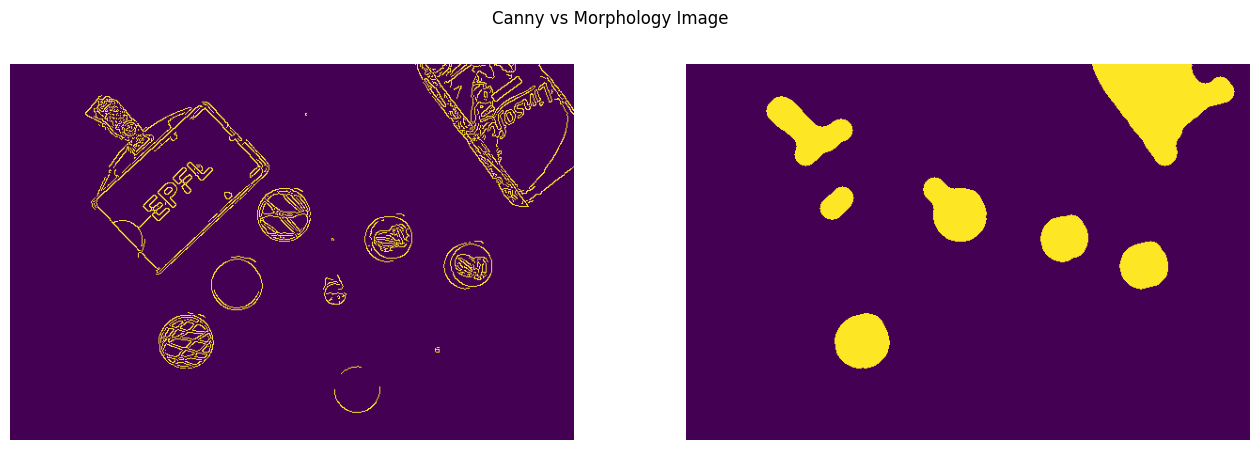

In [ ]:
label = train_labels[20]
pre.compare_2_images(
    image1=train_dict[label]['canny'],
    image2=train_dict[label]['canny_morph'],
    title="Canny vs Morphology Image")

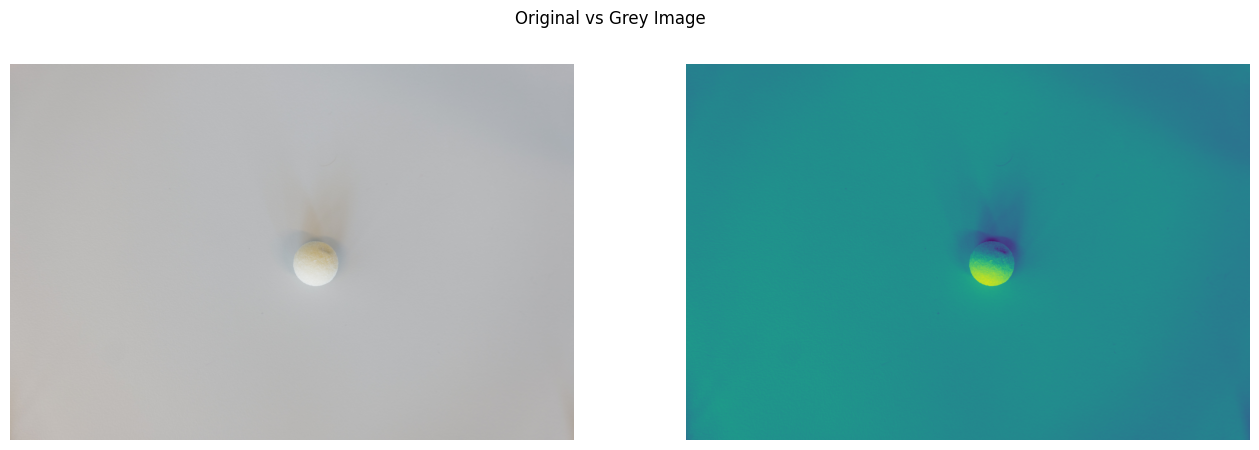

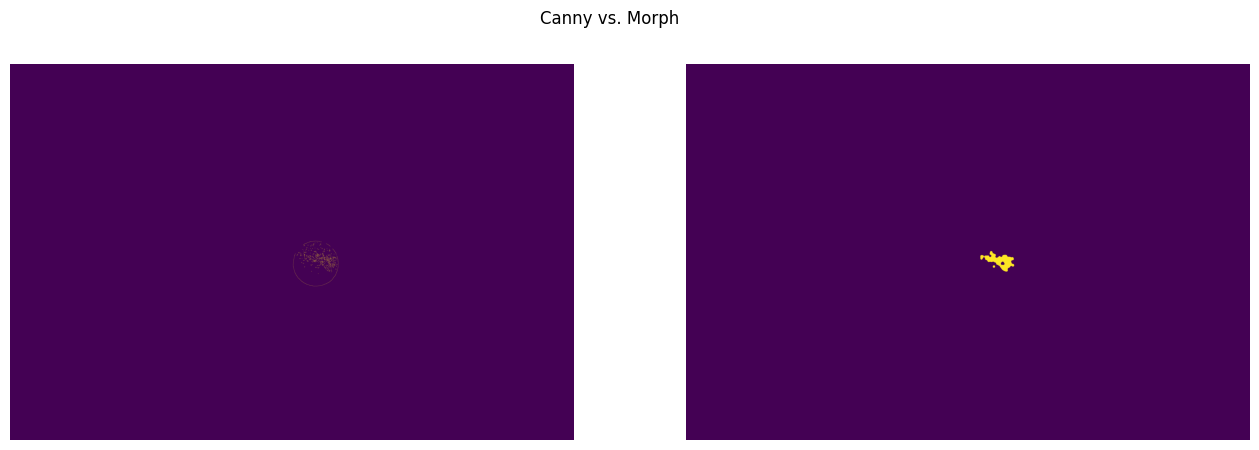

In [ ]:
k = 2
img = reference_images_raw[k]
grey = pre.RGB2greyscale(img)
canny = cv2.Canny(img, t_lower, t_upper, apertureSize=aperture_size, L2gradient=L2Gradient)
morph = lab1.apply_morphology(canny, kernel_size=kernel_size, min_area_th=min_area_th, min_obj_size=min_obj_size, connect=connect)
# Compare the original image and the thresholded image
pre.compare_2_images(
    image1=img,
    image2=grey,
    title="Original vs Grey Image")
pre.compare_2_images(
    image1=canny,
    image2=morph,
    title="Canny vs. Morph")



In [ ]:
def find_contour(image: np.ndarray):
    """
    Find the contours for a single image.

    Args
    ----
    image: np.ndarray (H, W)
        Source image to process (binary image).

    Return
    ------
    contours: list of np.ndarray
        List of arrays containing the coordinates of the contours. Each element of the 
        list is an array of 2D coordinates (K, 2) where K depends on the number of elements 
        that form the contour.
    """
    # Ensure the input image is binary
    binary_image = (image > 0).astype(np.uint8)

    # Find contours using OpenCV
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert contours to a list of arrays with shape (K, 2)
    contours = [contour.squeeze() for contour in contours if contour.size > 0]

    return contours

def simple_segmentation(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Thresholds for neutral/light backgrounds — adjust as needed
    lower = np.array([0, 0, 0])
    upper = np.array([100, 10, 180])

    # Create binary mask: 0 for background, 255 for foreground
    background_mask = cv2.inRange(hsv, lower, upper)
    foreground_mask = cv2.bitwise_not(background_mask)

    # Optional: morphological cleanup
    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(foreground_mask, cv2.MORPH_OPEN, kernel)

    return cleaned

In [ ]:
### Find Contours of all Reference Images and add them to the Dictionary ###

for dict in reference_dict.values():
    # Extract the image from the dictionary
    img = dict["canny_morph"]
    
    # Find contours
    contours = find_contour(img)
    
    # Add the new key-value pair to the dictionary
    dict["contours"] = contours

for dict in train_dict.values():
    # Extract the image from the dictionary
    img = dict["canny_morph"]
    
    # Find contours
    contours = find_contour(img)
    
    # Add the new key-value pair to the dictionary
    dict["contours"] = contours





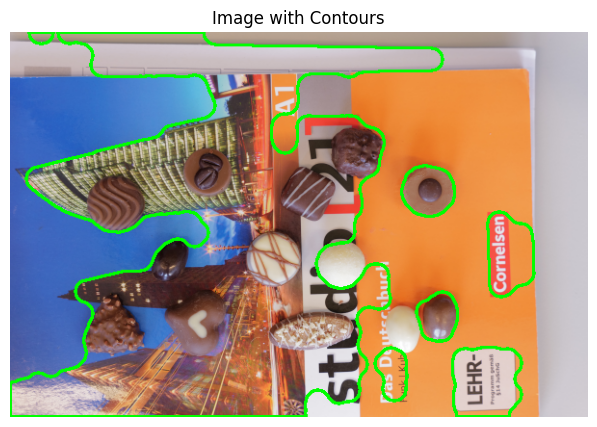

In [ ]:
# Plot the image with the contour on it
label = train_labels[50]
img = train_dict[label]['image']
contours = train_dict[label]['contours']

# Create a copy of the image to draw contours on
img_with_contours = img.copy()
# Draw contours on the image
for contour in contours:
    cv2.drawContours(img_with_contours, [contour], -1, (0, 255, 0), 2)  # Green color and thickness of 2
# Display the image with contours
plt.figure(figsize=(10, 5))
plt.imshow(img_with_contours)
plt.title('Image with Contours')
plt.axis('off')  # Turn off axis
plt.show()

In [ ]:
# # Get the comtesse Contour #
# img = reference_dict['Comtesse']['canny']
# contour = find_contour(img)
# print(f"Number of contours found: {len(contour)}")
# print(f"Contour shape: {contour[0].shape}")

# # Draw the contours on the original image
# img_with_contours = reference_dict['Comtesse']['image'].copy()
# # Draw only the first contour on the image

# cv2.drawContours(img_with_contours, [contour[2]], -1, (0, 255, 0), 2)  # Green color and thickness of 2
# cv2.drawContours(img_with_contours, [contour[3]], -1, (0, 255, 0), 2)  # Green color and thickness of 2

# # Display the image with contours
# plt.figure(figsize=(10, 5))
# plt.imshow(img_with_contours)
# plt.title('Image with Contours')
# plt.axis('off')  # Turn off axis
# plt.show()

# # Add the contours to the dictionary
# reference_dict['Comtesse']['contours'] = contour

In [ ]:
### Find the Bounding Boxes of the Contours for the Reference Images and Add them to the Dictionary ###

def find_bounding_boxes(image: np.ndarray, contours: list[np.ndarray]) -> list[np.ndarray]:
    """ Takes an image and its contour and returns the image within the bounding box of the contour.
    Args:
        contours: List of contours (each contour is a list of points)
    Returns:
        bbox_image: Image within the bounding box of the contour
    """
    # Save the bounding box images and bounding boxes
    bbox_images = []
    bboxes = []

    for contour in contours:
        # Compute the bounding box for the contour
        x, y, w, h = cv2.boundingRect(contour)
  
        # Extract the section of the image within the bounding box
        bbox_image = image[y:y+h, x:x+w]
        
        # Add the extracted section to the list
        bbox_images.append(bbox_image)
        bboxes.append((x, y, w, h))
    
    return bbox_images, bboxes


In [ ]:
### Add the raw image to the dictionary ###
for i, dict in enumerate(reference_dict.values()):
    # Extract the image from the dictionary
    raw_img = reference_images_raw[i]
    
    # Add the new key-value pair to the dictionary
    dict["raw_image"] = img

In [ ]:
### Find the bounding boxes for the reference images and add them to the dictionary ###
for dict in reference_dict.values():
    # Extract the image and contours from the dictionary
    img = dict["image"]
    contours = dict["contours"]
    
    # Find bounding boxes
    bbox_images, bboxes = find_bounding_boxes(img, contours)
    
    # Add the new key-value pair to the dictionary
    dict["bbox_images"] = bbox_images
    dict["bboxes"] = bboxes

# Collect bbox_images for all labels in reference_labels
bbox_images = [reference_dict[label]['bbox_images'] for label in reference_labels]


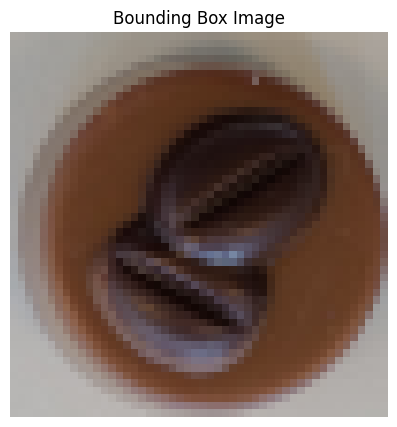

In [ ]:
# Plot the first bbox image
plt.figure(figsize=(10, 5))
plt.imshow(bbox_images[1][0])
plt.title('Bounding Box Image')
plt.axis('off')  # Turn off axis
plt.show()

In [ ]:
### Extract Color Profile from the Bounding Box Images ###
# Flatten and concatenate all pixels from all images
pixel_arrays = [img.reshape(-1, 3) for bbox in bbox_images for img in bbox]

cropped_images, cropped_color_profile = joint_kmeans_downsample(pixel_arrays, n_colors=256)
print(f"Reference color profile shape: {cropped_color_profile.shape}")
plot_color_profile(cropped_color_profile)

NameError: name 'joint_kmeans_downsample' is not defined

In [ ]:
def get_color_profile(reference_images):
    """
    Compute the unique RGB colors and their frequencies across all reference images using NumPy.

    Args:
        reference_images (List[np.ndarray]): List of (H, W, 3) RGB images

    Returns:
        unique_colors (np.ndarray): (N, 3) array of unique colors
        frequencies (np.ndarray): (N,) array of color frequencies
    """
    # Stack all image pixels into one big (total_pixels, 3) array
    all_pixels = np.concatenate([img.reshape(-1, 3) for img in reference_images], axis=0)

    # Convert to tuple-like for uniqueness check
    pixels_view = all_pixels.view([('', all_pixels.dtype)] * 3)

    # Get unique colors and their counts
    unique_pixels, counts = np.unique(pixels_view, return_counts=True)

    # Convert back to (N, 3) array
    unique_colors = unique_pixels.view(all_pixels.dtype).reshape(-1, 3)

    return unique_colors, counts

In [ ]:
def get_colors_inside_contours(reference_images: list[np.ndarray], contours: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the unique RGB colors and their frequencies for the pixels inside the contours of the reference images.

    Args:
        reference_images (list[np.ndarray]): List of (H, W, 3) RGB images.
        contours (list[np.ndarray]): List of contours (one contour per image).

    Returns:
        unique_colors (np.ndarray): (N, 3) array of unique colors.
        frequencies (np.ndarray): (N,) array of color frequencies.
    """
    all_pixels_inside_contours = []

    for image, contour in zip(reference_images, contours):
        # Create a mask for the current contour
        mask = np.zeros(image.shape[:2], dtype=np.uint8)  # Create a blank mask (same height and width as the image)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)  # Fill the contour on the mask

        # Extract the pixels inside the contour using the mask
        pixels_inside_contour = image[mask == 255]  # Get only the pixels where the mask is 255
        all_pixels_inside_contours.append(pixels_inside_contour)

    # Stack all pixels from all images into one array
    all_pixels_inside_contours = np.vstack(all_pixels_inside_contours)

    # Get unique colors and their counts
    pixels_view = all_pixels_inside_contours.view([('', all_pixels_inside_contours.dtype)] * 3)  # Convert to tuple-like for uniqueness
    unique_pixels, counts = np.unique(pixels_view, return_counts=True)  # Get unique colors and their counts

    # Convert back to (N, 3) array
    unique_colors = unique_pixels.view(all_pixels_inside_contours.dtype).reshape(-1, 3)

    return unique_colors, counts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_color_histogram(unique_colors: np.ndarray, frequencies: np.ndarray, sort: bool = True, top_n: int = 100):
    """
    Plot a histogram of color frequencies using actual color bars.

    Args:
        unique_colors (np.ndarray): (N, 3) array of RGB colors
        frequencies (np.ndarray): (N,) array of corresponding frequencies
        sort (bool): Whether to sort colors by frequency
        top_n (int): Max number of colors to show (for legibility)
    """
    if sort:
        sorted_idx = np.argsort(frequencies)[::-1]
        unique_colors = unique_colors[sorted_idx]
        frequencies = frequencies[sorted_idx]

    if top_n:
        unique_colors = unique_colors[:top_n]
        frequencies = frequencies[:top_n]

    fig, ax = plt.subplots(figsize=(16, 4))
    bar_width = 1.0 / len(unique_colors)

    for i, (color, freq) in enumerate(zip(unique_colors, frequencies)):
        color_hex = tuple(c / 255 for c in color)
        rect = patches.Rectangle(
            (i * bar_width, 0), bar_width, freq,
            facecolor=color_hex, edgecolor='black'
        )
        ax.add_patch(rect)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(frequencies) * 1.1)
    ax.axis('off')
    plt.title("Color Frequency Histogram")
    plt.tight_layout()
    plt.show()


In [ ]:
unique_colors, counts = get_color_profile(reference_images_raw)
print(f"Unique colors shape: {unique_colors.shape}")

In [ ]:
### Apply Color Profile Filter to Train Images and Add to Dictionary ###

# Apply the color profile filter to the train images
for dict in train_dict.values():
    # Extract the image from the dictionary
    img = dict["image"]
    
    # Apply the color profile filter
    img_filtered = _color_profile_filter(
        img,
        color_profile=cropped_color_profile,
        tolerance=50.0,
        return_mask=False,
        lab_space=True
    )
    
    # Add the new key-value pair to the dictionary
    dict["color_filtered"] = img_filtered


In [ ]:
# Plot the original image and the filtered image
label = train_labels[20]
# Compare the original image and the filtered image
pre.compare_2_images(
    image1=train_dict[label]['image'],
    image2=train_dict[label]['color_filtered'],
    title="Original vs Filtered Image")

In [ ]:
# Load image
image = reference_images[0]

# Create mask
mask = simple_segmentation(image)

# Create a blue background (same shape as image)
blue_background = np.full_like(image, (255, 0, 0))  # BGR for blue

# Combine chocolates with blue background
foreground = cv2.bitwise_and(image, image, mask=mask)
background = cv2.bitwise_and(blue_background, blue_background, mask=cv2.bitwise_not(mask))
result = cv2.add(foreground, background)

# Convert to RGB for display
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Background Replaced with Blue")
plt.axis("off")

plt.tight_layout()
plt.show()
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def get_binary_mask(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Threshold for neutral/light backgrounds
    lower = np.array([0, 0, 160])
    upper = np.array([180, 40, 255])

    background_mask = cv2.inRange(hsv, lower, upper)
    foreground_mask = cv2.bitwise_not(background_mask)

    # Morphological cleanup (optional)
    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(foreground_mask, cv2.MORPH_OPEN, kernel)

    # Convert to binary: 0 = foreground (chocolates), 1 = background
    binary_image = np.where(cleaned > 0, 0, 1).astype(np.uint8)

    return binary_image


In [ ]:
binary_mask = get_binary_mask(image)

# Display binary mask
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Image (0=Object, 1=Background)")
plt.axis('off')
plt.show()
mask = simple_segmentation(np.uint8(image))
result = cv2.bitwise_and(image, image, mask=mask)
# Convert to grayscale and preprocess (e.g., thresholding)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours = find_contour(binary_image)

# Draw contours in red on the original image
output_image = image.copy()
cv2.drawContours(output_image, contours, -1, (0, 0, 255), 2)  # Red color (BGR: (0, 0, 255)), thickness=2

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
plt.title("Contours in Red")
plt.axis('off')
plt.show()


In [ ]:
# clear the variable called dict
del dict

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

class EnhancedTruffleIdentifier:
    def __init__(self, reference_images, reference_labels, downscale_factor=1.0):
        """
        Args:
            reference_images: List of preprocessed reference images
            reference_labels: List of truffle type names  
            downscale_factor: Resize factor for faster processing (0.25 = 1/4 size)
        """
        self.sift = cv2.SIFT_create(
            nfeatures=2000,  # Reduced for downscaled images
            contrastThreshold=0.02,  # Slightly higher for stability
            edgeThreshold=10,
            sigma=1.0
        )
        
        # FLANN parameters
        self.index_params = dict(algorithm=1, trees=5)
        self.search_params = dict(checks=100)
        self.matcher = cv2.FlannBasedMatcher(self.index_params, self.search_params)
        
        # Store downscaled references
        self.ref_kps = []
        self.ref_des = [] 
        self.labels = []
        self.downscale_factor = downscale_factor
        
        for img, label in zip(reference_images, reference_labels):
            # Downscale reference image
            h, w = img.shape[:2]
            new_size = (int(w*downscale_factor), int(h*downscale_factor))
            img_small = cv2.resize(img, new_size)
            
            # Convert to grayscale and mask white background
            gray = cv2.cvtColor(img_small, cv2.COLOR_RGB2GRAY)
            _, mask = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)
            
            # Detect features
            kp, des = self.sift.detectAndCompute(gray, mask)
            
            if des is not None and len(des) > 10:  # Only keep if enough features
                self.ref_kps.append(kp)
                self.ref_des.append(des)
                self.labels.append(label)
                print(f"Loaded {label} with {len(des)} features")
            else:
                print(f"WARNING: {label} has insufficient features ({len(des) if des is not None else 0})")

    def identify_truffles(self, query_img, min_matches=10, reproj_thresh=3.0, match_ratio=0.8):
        """More robust matching with adjustable parameters"""
        # Downscale query image
        h, w = query_img.shape[:2]
        new_size = (int(w*self.downscale_factor), int(h*self.downscale_factor))
        query_small = cv2.resize(query_img, new_size)
        query_gray = cv2.cvtColor(query_small, cv2.COLOR_RGB2GRAY)
        
        # Detect query features
        query_kp, query_des = self.sift.detectAndCompute(query_gray, None)
        if query_des is None:
            print("No features detected in query image")
            return []
        
        results = []
        
        for i, (ref_des, label) in enumerate(zip(self.ref_des, self.labels)):
            try:
                matches = self.matcher.knnMatch(query_des, ref_des, k=2)
                
                # Lowe's ratio test with relaxed threshold
                good = []
                for m, n in matches:
                    if m.distance < match_ratio * n.distance:
                        good.append(m)
                
                if len(good) >= min_matches:
                    src_pts = np.float32([query_kp[m.queryIdx].pt for m in good])
                    dst_pts = np.float32([self.ref_kps[i][m.trainIdx].pt for m in good])
                    
                    # Find homography with RANSAC
                    M, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, reproj_thresh)
                    
                    if mask is not None:
                        inliers = np.sum(mask)
                        if inliers >= min_matches:
                            # Scale bounding box back to original size
                            h_ref, w_ref = reference_images[i].shape[:2]
                            ref_corners = np.float32([[0,0], [0,h_ref-1], [w_ref-1,h_ref-1], [w_ref-1,0]])
                            query_corners = cv2.perspectiveTransform(
                                ref_corners.reshape(-1,1,2), 
                                M * (1/self.downscale_factor)  # Scale transform
                            )
                            
                            # Create visualization (on downscaled images for speed)
                            vis = cv2.drawMatches(
                                query_small, query_kp,
                                cv2.resize(reference_images[i], new_size), self.ref_kps[i],
                                [m for m,valid in zip(good,mask) if valid],
                                None,
                                flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
                            )
                            
                            results.append((
                                label,
                                cv2.boundingRect(query_corners),
                                vis
                            ))
            except Exception as e:
                print(f"Error matching {label}: {str(e)}")
                continue
                
        return results

# Usage Example
identifier = EnhancedTruffleIdentifier(cropped_refrence_images, reference_labels)

test_img = train_images[2]  # Use your test image
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

results = identifier.identify_truffles(
    test_img_rgb,
    min_matches=8,            # Reduced from 15
    reproj_thresh=4.0,        # Increased from 2.5  
    match_ratio=0.8           # More lenient than 0.7
)

# Visualization
if len(results) > 0:
    for label, bbox, vis in results:
        x,y,w,h = bbox
        output_img = test_img_rgb.copy()
        cv2.rectangle(output_img, (x,y), (x+w,y+h), (0,255,0), 10)
        cv2.putText(output_img, label, (x,y-20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 2, (0,255,0), 3)
        
        plt.figure(figsize=(20,10))
        plt.subplot(121), plt.imshow(vis)
        plt.title(f"Feature Matches: {label}"), plt.axis('off')
        plt.subplot(122), plt.imshow(output_img)
        plt.title("Detection Result"), plt.axis('off')
        plt.show()
else:
    print("No matches found - try these adjustments:")
    print("1. Increase downscale_factor (up to 0.5)")
    print("2. Decrease min_matches (down to 5)") 
    print("3. Increase reproj_thresh (up to 5.0)")
    print("4. Increase match_ratio (up to 0.85)")